# Torun Reservoir — WAQ Model Output Analysis

**Period:** 1 April 2023 – 8 February 2024  
**Monitoring stations:** CAB and BIS (layers 8–16)

---
### Contents
1. Configuration & imports
2. File reading functions
3. Load observation data
4. Load model runs
5. Continuity plots
6. DO — all layers
7. DO — modelled vs observed (single run)
8. **Multi-run comparison** ← calibration iterations
9. Nutrients vs observations
10. Vertical profile comparisons
11. Light climate (Secchi / Kd)
12. Performance statistics table
13. Phytoplankton & Chlorophyll

## Phytoplankton Initial Conditions — Taxon to BLOOM Group Mapping

Initial conditions for phytoplankton were derived from field measurements collected at 
Location 01 (CAB) on **16/03/2023** (integrated water column sample). Biovolume data 
(mm³/L) was converted to BLOOM dry matter using group-specific C:volume ratios and 
BLOOM's DMCFALG parameter.

### Taxon → BLOOM Group Mapping

| BLOOM Group | Measured Taxa | Branch | Biovolume (mm³/L) |
|---|---|---|---|
| **FDIATOMS** | *Fragilaria crotonensis*, *Asterionella formosa*, *Pantocsekiella ocellata*, *Aulacoseira ambigua*, *Achnanthidium minutissimum*, *Nitzschia* spp., *Pseudostaurosira brevistriata*, *Encyonopsis subminuta* | BACILLARIOPHYTA | 0.2396 |
| **FFLAGELA** | *Plagioselmis nannoplanctica*, *Chroomonas coerulea*, *Cryptomonas* spp., *Pseudopedinella*, *Dinobryon divergens*, *Chrysochromulina parva*, *Kephyrion* | CRYPTOPHYTA + OCHROPHYTA + HAPTOPHYTA | 0.2600 |
| **GREENS** | *Chlamydomonas* <10µm, *Chlorella*, *Dictyosphaerium*, *Monoraphidium*, *Sphaerocystis*, *Planktosphaeria*, *Mychonastes* | CHLOROPHYTA | 0.0357 |
| **MICROCYS** | *Woronichinia naegeliana* | CYANOBACTERIA | 0.00199 |
| **APHANFIX, OSCILAT, ANABAENA** | Not detected in March 2023 sample | CYANOBACTERIA | 0.0 |
| **Not included** | *Trachelomonas volvocinopsis* | EUGLENOZOA | 0.00647 |

### Initial Conditions Applied in Model

| BLOOM Substance | IC Value (g DM/m³) | Derivation |
|---|---|---|
| FDIATOMS_E | 5.000e-02 | Biovolume conversion — diatom-dominated spring community |
| FDIATOMS_P | 2.500e-02 | 50% of FDIATOMS_E (P/Si ecotype fraction) |
| FFLAGELA | 2.600e-02 | Biovolume conversion — cryptophyte-dominated flagellate community |
| GREENS_E | 3.569e-03 | Biovolume conversion — small chlorophytes |
| GREENS_N | 1.785e-03 | 50% of GREENS_E (N ecotype fraction) |
| GREENS_P | 1.785e-03 | 50% of GREENS_E (P ecotype fraction) |
| MICROCYS_E | 1.991e-04 | Biovolume conversion — Woronichinia naegeliana only |
| MICROCYS_N | 9.955e-05 | 50% of MICROCYS_E |
| MICROCYS_P | 9.955e-05 | 50% of MICROCYS_E |
| APHANFIX, OSCILAT, ANABAENA | 0.0 | Not detected in March 2023 |

### Notes

- **Flagellates** in BLOOM (`FFLAGELA`) represent the cryptophyte-dominated flagellate 
  community (*Cryptomonas*, *Plagioselmis*) which was the largest biovolume group in the 
  March 2023 sample. In plots, FFLAGELA is grouped with GREENS for display purposes 
  as **Greens+Flagellates**.
- **Diatoms** were dominated by *Fragilaria crotonensis* and *Pantocsekiella ocellata*, 
  typical spring diatoms in temperate reservoirs.
- **Cyanobacteria** were represented only by *Woronichinia naegeliana* in March — a 
  colonial picocyanobacterium mapped to MICROCYS as the closest morphological match.
- *Trachelomonas volvocinopsis* (Euglenozoa) has no equivalent BLOOM freshwater group 
  and was excluded — its biovolume contribution is minor (0.006 mm³/L).
- Initial conditions were increased by a factor of ~2× from raw biovolume conversion 
  to account for sampling variability and population seeding requirements in BLOOM.

## 1. Configuration & Imports

In [1]:
import struct, os

def truncate_map(in_path, out_path, n_keep=5):
    """Copy the header + first n_keep timesteps of a DELWAQ .map into a new .map.
    Header parsing matches load_map: 4x40-char titles, n_sub, n_seg,
    n_sub x 20-char names, then (4-byte time + n_sub*n_seg*4 data) per step."""
    with open(in_path, 'rb') as f:
        header = f.read(160)                       # 4 x 40-char titles
        nsub_b, nseg_b = f.read(4), f.read(4)
        n_sub = struct.unpack('<i', nsub_b)[0]
        n_seg = struct.unpack('<i', nseg_b)[0]
        names = f.read(n_sub * 20)                 # substance names

        rec_size  = 4 + n_sub * n_seg * 4          # one timestep block
        file_size = os.path.getsize(in_path)
        hdr_size  = 160 + 8 + n_sub * 20
        n_total   = (file_size - hdr_size) // rec_size

        print(f'n_sub={n_sub}, n_seg={n_seg}, timesteps in file={n_total}')
        print(f'record size per timestep: {rec_size:,} bytes')

        n_keep = min(n_keep, n_total)
        with open(out_path, 'wb') as g:
            g.write(header); g.write(nsub_b); g.write(nseg_b); g.write(names)
            for _ in range(n_keep):
                block = f.read(rec_size)
                if len(block) < rec_size:
                    break
                g.write(block)

    out_size = os.path.getsize(out_path)
    print(f'Wrote {n_keep} timesteps -> {out_path}  ({out_size:,} bytes, '
          f'{out_size/1e6:.1f} MB)')


# ── edit these two paths, then run ──────────────────────────────────────────────
truncate_map(
    in_path  = r'<MODEL_DIR>\02scen\Torun_WAQ_Apr2023_scen02.map',          # <-- your Baseline .map
    out_path = r'<MODEL_DIR>\02scen\baseline_first5.map',
    n_keep   = 5,
)

n_sub=25, n_seg=10999, timesteps in file=1253
record size per timestep: 1,099,904 bytes
Wrote 5 timesteps -> <MODEL_DIR>\02scen\baseline_first5.map  (5,500,188 bytes, 5.5 MB)


In [2]:
import numpy as np
import pandas as pd
import struct, os, pickle
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from scipy import stats as sp_stats
import matplotlib.tri as tri
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9,
                     'axes.grid': True, 'grid.alpha': 0.3})

# ── PATHS — edit here only ─────────────────────────────────────────────────────
BASE = r'<MODEL_DIR>'

# Model runs: dict of {label: output_subfolder}
RUNS = {'Run42 (FasterSinking+spefile)': '01scen_baseline',
        'FPV scen02': '02scen',# update when ready
}
# Run to use for single-run plots (sections 5-6-7)
PRIMARY_RUN = 'Run42 (FasterSinking+spefile)'

# Reference time
T0 = datetime(2022, 9, 9, 0, 0, 0)

# Observation files
DO_TEK      = os.path.join(BASE, 'DO_measured_CAB.tek')
CHEM_FILE   = os.path.join(BASE, 'chemistry_CAB.tek')
CAB_MONTHLY = os.path.join(BASE, 'monthly_data_CAB01.csv')
BIS_MONTHLY = os.path.join(BASE, 'monthly_data_BIS.csv')
PAR_FILE    = os.path.join(BASE, 'monthly_PAR_BIS.csv')
PAR_CAB     = os.path.join(BASE, 'PAR_lakeCAB_measurements.csv')
ALGAE_TORCH = os.path.join(BASE, 'algae_torch_lakeCAB_measurements.csv')
DO_HF_FILE = os.path.join(BASE, 'data_DO_CAB.csv')
CHEM_FILE2 = os.path.join(BASE, 'CABANE_Water_Chemistry.xlsx')

CUTOFF = '2023-09-01'  # set to None to use full period

print('Configured runs:')
for label, folder in RUNS.items():
    if (label, folder) == list(RUNS.items())[-1]:
        path = os.path.join(BASE, folder, 'Torun_WAQ_Apr2023_scen02.his')
        exists = os.path.exists(path)
        size   = f"{os.path.getsize(path)/1e6:.1f} MB" if exists else 'NOT FOUND'
    else:
        path = os.path.join(BASE, folder, 'Torun_WAQ_Apr2023.his')
        exists = os.path.exists(path)
        size   = f"{os.path.getsize(path)/1e6:.1f} MB" if exists else 'NOT FOUND'
    print(f'  [{"OK" if exists else "!!"}] {label}: {size}')

Configured runs:
  [OK] Run42 (FasterSinking+spefile): 4.2 MB
  [OK] FPV scen02: 4.2 MB


## 2. File Reading Functions

In [3]:
def load_his(folder, runid='Torun_WAQ_Apr2023'):
    """Load a DELWAQ binary .his file. Returns dict with data and metadata."""
    his_file = os.path.join(BASE, folder, f'{runid}.his')
    with open(his_file, 'rb') as f:
        raw = f.read()
    pos   = 160  # skip 4×40-char description header
    n_sub = struct.unpack_from('<i', raw, pos)[0]; pos += 4
    n_loc = struct.unpack_from('<i', raw, pos)[0]; pos += 4
    substances = []
    for _ in range(n_sub):
        substances.append(raw[pos:pos+20].decode('latin-1').strip()); pos += 20
    locations = []
    for _ in range(n_loc):
        pos += 4  # skip 4-byte index prefix
        locations.append(raw[pos:pos+20].decode('latin-1').strip()); pos += 20
    rec_size  = 4 + n_loc * n_sub * 4
    n_times   = (len(raw) - pos) // rec_size
    times_sec = np.zeros(n_times, dtype=np.int32)
    data      = np.zeros((n_times, n_loc, n_sub), dtype=np.float32)
    for t in range(n_times):
        times_sec[t] = struct.unpack_from('<i', raw, pos)[0]; pos += 4
        vals = np.frombuffer(raw, dtype='<f4', count=n_loc*n_sub, offset=pos)
        data[t] = vals.reshape(n_loc, n_sub); pos += n_loc * n_sub * 4
    timestamps = [T0 + timedelta(seconds=int(s)) for s in times_sec]
    ts_index   = pd.DatetimeIndex(timestamps)
    # Build index helpers
    def find_sub(name):
        for i, s in enumerate(substances):
            if name.lower() in s.lower(): return i
        return None
    cab_locs, bis_locs = {}, {}
    for i, loc in enumerate(locations):
        l = loc.strip()
        if l.startswith('CAB (') and l.endswith(')'):
            cab_locs[int(l[5:-1].strip())] = i
        elif l.startswith('BIS (') and l.endswith(')'):
            bis_locs[int(l[5:-1].strip())] = i
    # Build idx from ALL substances in file — covers both fixed and extra history vars
    idx = {s: i for i, s in enumerate(substances)}
    # Also add partial-name lookups for backwards compatibility
    legacy_names = ['Continuity','OXY','NH4','NO3','PO4','Si',
                    'POC1','PON1','POP1','AAP','Opal',
                    'APHANFIX_E','FDIATOMS_E','FFLAGELA',
                    'GREENS_E','MICROCYS_E','OSCILAT_E','ANABAENA_E',
                    'APHANFIX_N','GREENS_N','MICROCYS_N','OSCILAT_N','ANABAENA_N',
                    'APHANFIX_P','GREENS_P','MICROCYS_P','OSCILAT_P','ANABAENA_P',
                    'FDIATOMS_P','MICROCYS_N','MICROCYS_P',
                    'DetCS1','DetNS1','DetPS1','DetSiS1','AAPS1','SatPercOXY',
                    'Chlfa','SedOXYDem',
                    'Limit Chlo','Limit nit','Limit pho','Limit sil',
                    'Limit e','Limit gro',
                    'RadAve','VWind','Temp','ExtVl']
    for name in legacy_names:
        if name not in idx:
            found = find_sub(name)
            if found is not None:
                idx[name] = found
    print(f"Loaded: {folder}")
    print(f"  {n_sub} substances, {n_loc} locations, {n_times} timesteps")
    print(f"  {timestamps[0].date()} -> {timestamps[-1].date()}")
    print(f"  idx contains {len(idx)} substances — Chlfa: {idx.get('Chlfa')}")
    if CUTOFF:
        mask       = ts_index <= pd.Timestamp(CUTOFF)
        data       = data[mask]
        timestamps = [t for t, m in zip(timestamps, mask) if m]
        ts_index   = pd.DatetimeIndex(timestamps)
    return dict(data=data, timestamps=timestamps, ts_index=ts_index,
                substances=substances, locations=locations,
                cab_locs=cab_locs, bis_locs=bis_locs,
                cab_avg=next((i for i,l in enumerate(locations) if 'CAB_av' in l), None),
                bis_avg=next((i for i,l in enumerate(locations) if 'BIS_av' in l), None),
                idx=idx)

def load_hisFPV(folder, runid='Torun_WAQ_Apr2023_scen02'):
    """Load a DELWAQ binary .his file. Returns dict with data and metadata."""
    his_file = os.path.join(BASE, folder, f'{runid}.his')
    with open(his_file, 'rb') as f:
        raw = f.read()

    pos   = 160  # skip 4×40-char description header
    n_sub = struct.unpack_from('<i', raw, pos)[0]; pos += 4
    n_loc = struct.unpack_from('<i', raw, pos)[0]; pos += 4

    substances = []
    for _ in range(n_sub):
        substances.append(raw[pos:pos+20].decode('latin-1').strip()); pos += 20

    locations = []
    for _ in range(n_loc):
        pos += 4  # skip 4-byte index prefix
        locations.append(raw[pos:pos+20].decode('latin-1').strip()); pos += 20

    rec_size  = 4 + n_loc * n_sub * 4
    n_times   = (len(raw) - pos) // rec_size
    times_sec = np.zeros(n_times, dtype=np.int32)
    data      = np.zeros((n_times, n_loc, n_sub), dtype=np.float32)

    for t in range(n_times):
        times_sec[t] = struct.unpack_from('<i', raw, pos)[0]; pos += 4
        vals = np.frombuffer(raw, dtype='<f4', count=n_loc*n_sub, offset=pos)
        data[t] = vals.reshape(n_loc, n_sub); pos += n_loc * n_sub * 4

    timestamps = [T0 + timedelta(seconds=int(s)) for s in times_sec]
    ts_index   = pd.DatetimeIndex(timestamps)

    # Build index helpers
    def find_sub(name):
        for i, s in enumerate(substances):
            if name.lower() in s.lower(): return i
        return None

    cab_locs, bis_locs = {}, {}
    for i, loc in enumerate(locations):
        l = loc.strip()
        if l.startswith('CAB (') and l.endswith(')'):
            cab_locs[int(l[5:-1].strip())] = i
        elif l.startswith('BIS (') and l.endswith(')'):
            bis_locs[int(l[5:-1].strip())] = i

    idx = {s: find_sub(s) for s in ['Continuity','OXY','NH4','NO3','PO4','Si',
                                     'POC1','PON1','POP1','AAP','Opal',
                                     'APHANFIX_E','FDIATOMS_E','FFLAGELA',
                                     'GREENS_E','MICROCYS_E','OSCILAT_E','ANABAENA_E',
                                     'APHANFIX_N','GREENS_N','MICROCYS_N','OSCILAT_N','ANABAENA_N',
                                     'APHANFIX_P','GREENS_P','MICROCYS_P','OSCILAT_P','ANABAENA_P',
                                     'DetCS1','DetNS1','DetPS1','AAPS1','SatPercOXY']}

    print(f"Loaded: {folder}")
    print(f"  {n_sub} substances, {n_loc} locations, {n_times} timesteps")
    print(f"  {timestamps[0].date()} → {timestamps[-1].date()}")

    if CUTOFF:
        mask       = ts_index <= pd.Timestamp(CUTOFF)
        data       = data[mask]
        timestamps = [t for t, m in zip(timestamps, mask) if m]
        ts_index   = pd.DatetimeIndex(timestamps)

    return dict(data=data, timestamps=timestamps, ts_index=ts_index,
                substances=substances, locations=locations,
                cab_locs=cab_locs, bis_locs=bis_locs,
                cab_avg=next((i for i,l in enumerate(locations) if 'CAB_av' in l), None),
                bis_avg=next((i for i,l in enumerate(locations) if 'BIS_av' in l), None),
                idx=idx)


def get_corrected(run, sub_name, loc_idx):
    """Return continuity-corrected time series for a substance at a location."""
    d    = run['data']
    i_s  = run['idx'].get(sub_name)
    i_c  = run['idx']['Continuity']
    if i_s is None: return np.full(len(run['timestamps']), np.nan)
    cont = d[:, loc_idx, i_c]
    return np.where(np.abs(cont) > 0.01, d[:, loc_idx, i_s] / cont, np.nan)


def compute_aggregates(run, locs_dict, layer_depths_dict, max_depth):
    """Compute depth-averaged TotN, TotP, TOC, DIN."""
    def avg(sub):
        return get_depth_averaged(run, sub, locs_dict,
                                  layer_depths_dict, max_depth)

    # P:DM ratios from .spe (PCRALG / DMCFALG for each P ecotype)
    p_dm = {
        'APHANFIX_P': 0.0088 / 2.5,
        'FDIATOMS_P': 0.0113 / 2.5,
        'GREENS_P':   0.0125 / 2.5,
        'MICROCYS_P': 0.0225 / 2.5,
        'OSCILAT_P':  0.0113 / 2.5,
        'ANABAENA_P': 0.0100 / 2.5,
    }

    # N:DM ratios from .spe (NCRALG / DMCFALG for each N ecotype)
    n_dm = {
        'APHANFIX_N': 0.125 / 2.5,
        'GREENS_N':   0.175 / 2.5,
        'MICROCYS_N': 0.113 / 2.5,
        'OSCILAT_N':  0.125 / 2.5,
        'ANABAENA_N': 0.113 / 2.5,
    }

    # E ecotype C:DM ratio (1/DMCFALG)
    c_dm = 1.0 / 2.5

    din  = avg('NH4') + avg('NO3')
    totn = din + avg('PON1') + sum(avg(s) * n_dm[s] for s in n_dm
                                   if run['idx'].get(s) is not None)
    totp = avg('PO4') + avg('POP1') + avg('AAPS1') + \
           sum(avg(s) * p_dm[s] for s in p_dm
               if run['idx'].get(s) is not None)
    toc  = avg('POC1') + avg('DetCS1') + \
           sum(avg(s) * c_dm for s in
               ['APHANFIX_E','FDIATOMS_E','FFLAGELA','GREENS_E',
                'MICROCYS_E','OSCILAT_E','ANABAENA_E']
               if run['idx'].get(s) is not None)

    return dict(DIN=din, TotN=totn, TotP=totp*1000, TotP_mgL=totp, TOC=toc)

def get_tem_profile(target_date, locs_dict, layer_depths_dict, n_seg=10999):
    """Extract modelled temperature profile from .tem segment function file."""
    tem_path    = os.path.join(BASE, 'com-WQexport_clean.tem')
    raw         = np.fromfile(tem_path, dtype='<f4')
    rec_size    = n_seg + 1
    n_rec       = len(raw) // rec_size
    times_sec   = raw[0::rec_size][:n_rec]
    target_sec  = (pd.Timestamp(target_date) - T0).total_seconds()
    nearest_idx = int(np.argmin(np.abs(times_sec - target_sec)))
    mod_vals, mod_z = [], []
    for layer, depth in sorted(layer_depths_dict.items()):
        if layer in locs_dict:
            seg_idx = locs_dict[layer]
            temp    = raw[nearest_idx * rec_size + 1 + seg_idx]
            mod_vals.append(float(temp))
            mod_z.append(depth)
    return mod_vals, mod_z

def get_depth_averaged(run, sub_name, locs_dict, layer_depths_dict, max_depth):
    """Compute depth-averaged substance concentration weighted by layer thickness."""
    # Layer mid-depths and approximate thicknesses
    layer_bounds = {
        8:  (0.00, 0.55),   # 0.00 – 0.55m
        9:  (0.55, 1.46),   # 0.55 – 1.46m
        10: (1.46, 2.45),   # 1.46 – 2.45m
        11: (2.45, 3.40),   # 2.45 – 3.40m
        12: (3.40, 4.45),   # 3.40 – 4.45m
        13: (4.45, 5.80),   # 4.45 – 5.80m
        14: (5.80, 7.30),   # 5.80 – 7.30m
        15: (7.30, 8.30),   # 7.30 – 8.30m
        16: (8.30, 8.60),   # 8.30 – 8.60m
    }
    layers  = [l for l in sorted(locs_dict.keys())
               if layer_depths_dict.get(l, 999) <= max_depth]
    weights = []
    values  = []
    for l in layers:
        top, bot  = layer_bounds[l]
        thickness = min(bot, max_depth) - top
        val       = get_corrected(run, sub_name, locs_dict[l])
        weights.append(thickness)
        values.append(val)
    weights = np.array(weights)
    values  = np.array(values)   # shape: (n_layers, n_times)
    return np.average(values, axis=0, weights=weights)

print('Functions defined.')

Functions defined.


In [4]:
def load_map(map_path):
    """Read DELWAQ .map binary — no Fortran record markers.
    Data stored as (n_seg, n_sub) per timestep, transposed to (n_sub, n_seg)."""
    with open(map_path, 'rb') as f:
        # 4 × 40-char title strings
        titles    = [f.read(40).decode('latin-1').strip() for _ in range(4)]
        # n_sub, n_seg
        n_sub     = struct.unpack('<i', f.read(4))[0]
        n_seg     = struct.unpack('<i', f.read(4))[0]
        # substance names (n_sub × 20 chars)
        sub_names = [f.read(20).decode('latin-1').strip()
                     for _ in range(n_sub)]

        print(f'Titles: {titles[:2]}')
        print(f'n_sub={n_sub}, n_seg={n_seg}')
        print(f'Substances: {sub_names}')

        # Read all timesteps
        timestamps = []
        frames     = []
        while True:
            t_bytes = f.read(4)
            if len(t_bytes) < 4:
                break
            time_sec = struct.unpack('<i', t_bytes)[0]
            raw      = f.read(n_sub * n_seg * 4)
            if len(raw) < n_sub * n_seg * 4:
                break
            # Stored as (n_seg, n_sub) — transpose to (n_sub, n_seg)
            data = np.frombuffer(raw, dtype='<f4')\
                     .reshape(n_seg, n_sub).T.copy()
            timestamps.append(time_sec)
            frames.append(data)

    t0 = pd.Timestamp('2022-09-09')
    ts = [t0 + pd.Timedelta(seconds=int(s)) for s in timestamps]
    print(f'Timesteps: {len(ts)}')
    print(f'Period: {ts[0].date()} → {ts[-1].date()}')

    return {
        'timestamps': ts,
        'substances': sub_names,
        'idx':        {s: i for i, s in enumerate(sub_names)},
        'data':       np.array(frames),   # shape: (n_times, n_sub, n_seg)
        'n_seg':      n_seg,
        'n_sub':      n_sub,
    }

## 3. Load Observation Data

In [5]:
# ── Monthly chemistry (new extended dataset) ──────────────────────────────────
chem2 = pd.read_excel(CHEM_FILE2, parse_dates=['Date'])
chem2 = chem2.set_index('Date').sort_index()

# Clean <0.010 and <0.001 values — replace with half detection limit
for col in chem2.columns:
    if chem2[col].dtype == object:
        chem2[col] = chem2[col].replace({'<0.010': 0.005, '<0.001': 0.0005})
        chem2[col] = pd.to_numeric(chem2[col], errors='coerce')

# Rename to match existing obs_chem column names
chem2 = chem2.rename(columns={
    'C_Total_mg/L':       'C_Total',
    'N_Total_mg/L':       'N_Total',
    'P_Total_microg/L':   'P_Total_ugL',
    'P-PO4_mg/L':         'P_PO4',
    'N-NH4_mg/L':         'N_NH4',
    'N-NO3_mg/L':         'N_NO3',
    'N-NO2_mg/L':         'N_NO2',
    'COD_mg/L':           'COD',
    'SiO2':               'SiO2',
})

# Filter to simulation period for main plots
chem2_sim = chem2.loc['2023-04-01':'2023-09-01']
print(f'Extended chemistry: {len(chem2)} total records, '
      f'{len(chem2_sim)} within simulation period')

Extended chemistry: 15 total records, 5 within simulation period


In [6]:
# ── High-frequency DO + saturation ───────────────────────────────────────────
obs_hf = pd.read_csv(DO_HF_FILE, parse_dates=['date'])
obs_hf = obs_hf.drop_duplicates('date').set_index('date').sort_index()
obs_hf = obs_hf[obs_hf.index <= pd.Timestamp('2023-09-01')]
obs_hf_daily_do  = obs_hf['DO_mgl'].resample('D').mean()
obs_hf_daily_sat = obs_hf['DO_sat_percentage'].resample('D').mean()
print(f"HF DO records: {len(obs_hf)}, period: {obs_hf.index[0].date()} → {obs_hf.index[-1].date()}")

# ── Chemistry (grab samples) ──────────────────────────────────────────────────
chem_cols = ['C_Total','N_Total','P_Total_ugL','P_PO4','N_NH4','N_NO3','N_NO2','COD','SiO2']
rows = []
with open(CHEM_FILE, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 11 and parts[0].isdigit():
            rows.append([datetime.strptime(parts[0]+parts[1].zfill(6),'%Y%m%d%H%M%S')] +
                        [float(v) for v in parts[2:]])
obs_chem = pd.DataFrame(rows, columns=['time']+chem_cols).set_index('time')
obs_chem = obs_chem.replace(-999.0, np.nan)
obs_chem['P_Total'] = obs_chem['P_Total_ugL'] * 0.001
obs_chem = obs_chem.loc['2023-04-01':'2024-02-08']
print(f'Chemistry obs: {len(obs_chem)} samples')

# ── Monthly profiles ──────────────────────────────────────────────────────────
cab_prof = pd.read_csv(CAB_MONTHLY, parse_dates=['time'], encoding='latin-1')
par_df   = pd.read_csv(PAR_FILE, parse_dates=['time'])
secchi_obs = cab_prof.drop_duplicates('time')[['time','Secchi (cm)']].dropna().copy()
secchi_obs['Secchi_m'] = secchi_obs['Secchi (cm)'] / 100
secchi_obs = secchi_obs[secchi_obs['time'] >= '2023-04-01']

# Kd from PAR profiles
kd_rows = []
for (dt, site), grp in par_df.groupby([par_df['time'].dt.date, 'Site']):
    grp  = grp.sort_values('Prof PAR')
    surf = grp[grp['Prof PAR'] == 0.0]['PAR'].values
    if len(surf) == 0: continue
    deep = grp[grp['Prof PAR'] > 0].iloc[-1]
    if deep['PAR'] > 0:
        Kd = -np.log(deep['PAR']/surf[0]) / deep['Prof PAR']
        kd_rows.append({'date': pd.Timestamp(dt), 'site': site,
                        'Kd': Kd, 'Secchi_PAR': 1.7/Kd})
kd_df = pd.DataFrame(kd_rows)
print(f'PAR surveys: {len(kd_df)} profiles')

# ── High-frequency DO from .tek file (original sensor data) ──────────────────
do_rows = []
with open(DO_TEK, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 3 and parts[0].isdigit():
            try:
                do_rows.append({
                    'time':   datetime.strptime(parts[0]+parts[1].zfill(6), '%Y%m%d%H%M%S'),
                    'DO_obs': float(parts[2])
                })
            except:
                pass
obs_do = pd.DataFrame(do_rows).set_index('time').sort_index()
obs_do = obs_do.loc['2023-04-01':'2023-09-01']
print(f'DO obs: {len(obs_do)} records')

obs_hourly = obs_do.resample('1H').mean()

obs_hourly = obs_do.resample('1H').mean()
print('\nAll observations loaded.')

HF DO records: 22032, period: 2023-04-01 → 2023-08-31
Chemistry obs: 9 samples
PAR surveys: 26 profiles
DO obs: 32770 records

All observations loaded.


In [7]:
# ── PAR profiles → Kd via Beer-Lambert linear regression ─────────────────────
par_df = pd.read_csv(PAR_CAB, encoding='latin-1')
par_df['Date'] = pd.to_datetime(par_df['Date'], dayfirst=True)
par_df['Site'] = par_df['Site'].str.strip()
par_df['PAR']  = pd.to_numeric(par_df['PAR'], errors='coerce')
par_df         = par_df.dropna(subset=['PAR'])

kd_par_records = []
for (serie, site), grp in par_df.groupby(['Serie_id', 'Site']):
    grp  = grp.sort_values('Prof PAR')
    z    = grp['Prof PAR'].values.astype(float)
    par  = grp['PAR'].values.astype(float)
    mask = par > 0
    if mask.sum() < 2:
        continue
    slope, _, _, _, _ = sp_stats.linregress(z[mask], np.log(par[mask]))
    kd = -slope
    if kd > 0:
        kd_par_records.append({
            'date':       grp['Date'].iloc[0],
            'site':       site,
            'Kd':         kd,
            'Secchi_PAR': 1.7 / kd
        })

kd_par_df = pd.DataFrame(kd_par_records)
print(f"PAR Kd records: {len(kd_par_df)}")

# ── Algae torch → average replicates per survey date/site ────────────────────
torch_df = pd.read_csv(ALGAE_TORCH, encoding='latin-1')
torch_df['Date'] = pd.to_datetime(torch_df['Date'], dayfirst=True)
torch_df['Site'] = torch_df['Site'].str.strip()

torch_mean = (torch_df.groupby(['Date', 'Site'])
              [['Cyano', 'Chloro Tot', 'Turbi']]
              .mean()
              .reset_index())

# CAB and BIS subsets within simulation period
torch_cab = torch_mean[
    (torch_mean['Site'] == 'CAB') &
    (torch_mean['Date'] >= pd.Timestamp('2023-04-01')) &
    (torch_mean['Date'] <= pd.Timestamp('2023-09-01'))
]
torch_bis = torch_mean[
    (torch_mean['Site'] == 'CAB_BIS') &
    (torch_mean['Date'] >= pd.Timestamp('2023-04-01')) &
    (torch_mean['Date'] <= pd.Timestamp('2023-09-01'))
]
print(f"Algae torch CAB records (sim period): {len(torch_cab)}")
print(f"Algae torch BIS records (sim period): {len(torch_bis)}")

PAR Kd records: 22
Algae torch CAB records (sim period): 5
Algae torch BIS records (sim period): 4


## 4. Load Model Runs

In [8]:
RUNS

{'Run42 (FasterSinking+spefile)': '01scen_baseline', 'FPV scen02': '02scen'}

In [9]:
# Load all configured runs — skip missing ones
li = [('Run39 (DynDepth)', 'output_data_run39'),
      ('Run40 (NoDepAve+LowerVSedAlg)', 'output_data_run40'),('Run41 (FastSinking)', 'output_data_run41'),
      ('Run42 (FasterSinking+spefile)', 'output_data_run42'),('Run43 (Sediment)', 'output_data_run43'),]
runs = {}
for label, folder in li:
    path = os.path.join(BASE, folder, 'Torun_WAQ_Apr2023.his')
    if os.path.exists(path):
        runs[label] = load_his(folder)
    else:
        print(f'SKIPPING {label} — file not found')

path = os.path.join(BASE, folder, 'Torun_WAQ_Apr2023_scen02.his')
runs['FPV scen02'] = load_hisFPV('02scen')

# Shortcut to primary run
R = runs[PRIMARY_RUN]
print(f"\nPrimary run: {PRIMARY_RUN}")

SKIPPING Run39 (DynDepth) — file not found
SKIPPING Run40 (NoDepAve+LowerVSedAlg) — file not found
SKIPPING Run41 (FastSinking) — file not found
Loaded: output_data_run42
  42 substances, 20 locations, 1253 timesteps
  2023-04-01 -> 2024-02-08
  idx contains 42 substances — Chlfa: 36
SKIPPING Run43 (Sediment) — file not found
Loaded: 02scen
  42 substances, 20 locations, 1253 timesteps
  2023-04-01 → 2024-02-08

Primary run: Run42 (FasterSinking+spefile)


In [10]:
print(R['substances'])

['Continuity', 'OXY', 'AAP', 'POC1', 'PON1', 'POP1', 'Opal', 'NH4', 'NO3', 'PO4', 'Si', 'FDIATOMS_E', 'FDIATOMS_P', 'FFLAGELA', 'GREENS_E', 'GREENS_N', 'GREENS_P', 'MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P', 'AAPS1', 'DetCS1', 'DetNS1', 'DetPS1', 'DetSiS1', 'SatPercOXY', 'Limit Chlo', 'Limit nit', 'Limit pho', 'Limit sil', 'Limit e', 'Limit gro', 'RadAve', 'VWind', 'Temp', 'ExtVl', 'Chlfa', 'SedOXYDem', 'BloomDepth', 'DayL', 'Depth', 'SecchiDept']


## 5. Continuity Plots

In [11]:
def plot_continuity(run):
    layer_depths = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                    13: 5.0, 14: 6.6, 15: 8.0, 16: 8.6}

    layers     = sorted(run['cab_locs'].keys())
    ts         = run['timestamps']

    plot_items = [(None, run['cab_avg'], run['bis_avg'])] + \
                 [(l, run['cab_locs'][l], run['bis_locs'][l]) for l in layers]

    n_plots = len(plot_items)
    n_cols  = 2
    n_rows  = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 1.1*n_rows), sharex = True)
    axes_flat = axes.flatten()

    for idx_plot, (ax, (lyr, li_cab, li_bis)) in enumerate(zip(axes_flat, plot_items)):
        cont_cab = run['data'][:, li_cab, run['idx']['Continuity']]
        cont_bis = run['data'][:, li_bis, run['idx']['Continuity']]

        label    = 'Depth-averaged' if lyr is None else f'Depth: {layer_depths[lyr]} m'
        panel_id = f'({chr(97 + idx_plot)})'

        ax.plot(ts, cont_cab, color='steelblue', lw=0.7,
                label=f'Loc 01 (mean={np.nanmean(cont_cab):.3f}, std={np.nanstd(cont_cab):.3f})')
        ax.plot(ts, cont_bis, color='darkorange', lw=0.7, ls='--',
                label=f'Loc 02 (mean={np.nanmean(cont_bis):.3f}, std={np.nanstd(cont_bis):.3f})')
        ax.axhline(1.0, color='black', ls='-', lw=0.5)
        ax.set_ylim(0.8, 1.2)
        ax.legend(fontsize=6, loc='upper right')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.text(0.02, 0.95, f'{panel_id} {label}', transform=ax.transAxes,
                fontsize=7, va='top', ha='left')
        ax.tick_params(axis='both', labelsize=7)

    # Hide unused subplots
    for ax in axes_flat[n_plots:]:
        ax.set_visible(False)

    # Shared y-axis label
    fig.text(0.015, 0.5, 'Continuity [g/m³]', va='center', rotation='vertical', fontsize=8)

    plt.tight_layout()
    plt.subplots_adjust(left=0.08)
    out = os.path.join(BASE, RUNS[PRIMARY_RUN], 'Continuity_CAB_BIS.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()

plot_continuity(R)

<Figure size 840x660 with 10 Axes>

## 6. DO — All Layers

In [12]:
def plot_DO_layers(run, station):
    layer_depths = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                    13: 5.0, 14: 6.6, 15: 8.0, 16: 8.6}
    max_depths   = {'CAB': 8.0, 'BIS': 7.0}
    loc_ids      = {'CAB': 'Loc 01', 'BIS': 'Loc 02'}
    colours      = {'CAB': 'steelblue', 'BIS': 'darkorange'}

    locs   = run['cab_locs'] if station == 'CAB' else run['bis_locs']
    avg    = run['cab_avg']  if station == 'CAB' else run['bis_avg']
    loc_id = loc_ids[station]
    max_d  = max_depths[station]
    colour = colours[station]

    layers     = [l for l in sorted(locs.keys()) if layer_depths.get(l, 999) <= max_d]
    ts_idx     = run['ts_index']
    plot_items = [(None, avg)] + [(l, locs[l]) for l in layers]

    # ── Daily timestamps ───────────────────────────────────────────────────────
    ts_daily = pd.date_range(
        start=ts_idx[0].normalize(),
        end=ts_idx[-1].normalize(),
        freq='D'
    )

    def to_daily(arr):
        return pd.Series(arr, index=ts_idx).resample('D').mean().reindex(ts_daily)

    n_plots = len(plot_items)
    n_cols  = 2
    n_rows  = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 1*n_rows),
                             sharex=True, sharey=True)
    axes_flat = axes.flatten()

    for idx_plot, (ax, (lyr, li)) in enumerate(zip(axes_flat, plot_items)):
        do_raw  = run['data'][:, li, run['idx']['OXY']]
        do_corr = get_corrected(run, 'OXY', li)

        do_raw_d  = to_daily(do_raw)
        do_corr_d = to_daily(do_corr)

        label    = 'Depth-averaged' if lyr is None else f'Depth: {layer_depths[lyr]} m'
        panel_id = f'({chr(97 + idx_plot)})'

        ax.plot(ts_daily, do_raw_d,  color=colour, lw=0.6, alpha=0.3)
        ax.plot(ts_daily, do_corr_d, color=colour, lw=0.7,
                label=f'{loc_id} (max {max_d} m)')
        ax.legend(fontsize=6, loc='upper right')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.text(0.02, 0.9, f'{panel_id} {label}', transform=ax.transAxes,
                fontsize=7, va='top', ha='left')
        ax.tick_params(axis='both', labelsize=7)
        ax.yaxis.set_major_locator(plt.MultipleLocator(2.0))
        ax.yaxis.set_minor_locator(plt.MultipleLocator(1.0))
        ax.grid(True, which='both', axis='y', alpha=0.3)

        if run['idx'].get('SatPercOXY') is not None:
            do_sat   = get_corrected(run, 'SatPercOXY', li)
            do_sat_d = to_daily(do_sat)
            ax2 = ax.twinx()
            ax2.plot(ts_daily, do_sat_d, color='darkred', lw=0.7,
                     ls='--', alpha=0.9, label='Sat %')
            ax2.tick_params(axis='y', labelsize=6, labelcolor='darkred')
            ax2.set_ylim(0, 150)
            ax2.yaxis.set_major_locator(plt.MultipleLocator(50))

    # Enable x labels on the last panel of each column
    for col in range(n_cols):
        last_in_col = [i for i in range(n_plots) if i % n_cols == col]
        if last_in_col:
            axes_flat[last_in_col[-1]].tick_params(axis='x', labelbottom=True,
                                                    labelsize=7)
    for ax in axes_flat[n_plots:]:
        ax.set_visible(False)

    fig.text(0.015, 0.5, 'DO [g/m³]', va='center', rotation='vertical', fontsize=8)
    fig.text(0.985, 0.5, 'Sat [%]', va='center', rotation='vertical',
             fontsize=8, color='darkred')
    plt.tight_layout()
    plt.subplots_adjust(left=0.08, right=0.92, top=0.95, hspace=0.15, wspace=0.15)
    out = os.path.join(BASE, RUNS[PRIMARY_RUN], f'DO_{station}_layers.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()

plot_DO_layers(R, 'CAB')
# plot_DO_layers(R, 'BIS')

<Figure size 840x600 with 19 Axes>

## 7. DO — Modelled vs Observed (Single Run)

In [13]:
obs_depth = 0.70   # sensor at 0.70m — between layer 8 (0.16m) and layer 9 (0.93m)
# Not interpolating data.
# Modelled DO — CAB only
do_l8     = get_corrected(R, 'OXY', R['cab_locs'][8])
do_l9     = get_corrected(R, 'OXY', R['cab_locs'][9])

# Modelled DO interpolated to 0.7m — CAB only
do_daily  = pd.Series(do_l9, index=R['ts_index']).resample('D').mean()

do_surf_daily = pd.Series(do_l8, index=R['ts_index']).resample('D').mean()

# Modelled SatPercOXY — CAB only
sat_l8     = get_corrected(R, 'SatPercOXY', R['cab_locs'][8])
sat_l9     = get_corrected(R, 'SatPercOXY', R['cab_locs'][9])

sat_daily  = pd.Series(sat_l9, index=R['ts_index']).resample('D').mean()

sat_surf_daily = pd.Series(sat_l8, index=R['ts_index']).resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(5, 4.5), sharex=True)

# Panel (a) — Surface DO, 0.16m depth
obs_daily = obs_do.loc[:'2023-09-01'].resample('D').mean()
axes[0].scatter(obs_daily.index, obs_daily.DO_obs, s=10, color='red', alpha=0.6,
                label='Observed daily mean (0.7 m)', zorder=5)
axes[0].plot(do_surf_daily.index, do_surf_daily.values, 'b-', lw=1.0,
             label='Modelled (max 0.16m)')
axes[0].plot(do_daily.index, do_daily.values, 'b--', lw=1.0,
             label='Modelled (max 0.93m)')

axes[0].set_ylabel('Dissolved oxygen [mg/L]', fontsize=8)
axes[0].set_ylim(3, 15)
axes[0].legend(fontsize=7, loc='lower left')
axes[0].tick_params(axis='both', labelsize=8)
axes[0].text(0.02, 0.92, '(a) Dissolved Oxygen — Loc 01',
             transform=axes[0].transAxes, fontsize=8, va='top', ha='left')

# Panel (b) — DO saturation %
axes[1].scatter(obs_hf_daily_sat.index, obs_hf_daily_sat.values,
                s=10, color='red', alpha=0.6, marker = '*',
                label='Observed daily mean (0.7 m)', zorder=5)
axes[1].plot(sat_surf_daily.index, sat_surf_daily.values, 'b-', lw=1.0,
             label='Modelled (max 0.16m)')
axes[1].plot(sat_daily.index, sat_daily.values, 'b--', lw=1.0,
             label='Modelled (max 0.93m)')

axes[1].axhline(100, color='grey', ls='--', lw=0.8, alpha=0.5)
axes[1].set_ylabel('DO Saturation [%]', fontsize=8)
axes[1].set_ylim(50, 160)
axes[1].yaxis.set_major_locator(plt.MultipleLocator(25))
axes[1].legend(fontsize=7, loc='lower left')
axes[1].tick_params(axis='both', labelsize=8)
axes[1].text(0.02, 0.92, '(b) DO Saturation — Loc 01',
             transform=axes[1].transAxes, fontsize=8, va='top', ha='left')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))

plt.tight_layout()
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'DO_CAB_vs_obs_completeplot.png'),
            dpi=150, bbox_inches='tight')
plt.show()

<Figure size 600x540 with 2 Axes>

## 8. Multi-Run Comparison

In [14]:
def get_run_colours(n):
    """Generate n distinct colours from a colormap."""
    cmap = plt.cm.get_cmap('tab10', n)
    return [cmap(i) for i in range(n)]

def compare_runs_DO():
    """Plot all loaded runs vs observed DO interpolated to 0.3m."""
    obs_depth = 0.70
    z1, z2    = 0.16, 0.93
    w2        = (obs_depth - z1) / (z2 - z1)
    w1        = 1 - w2

    obs_daily = obs_do.loc[:'2023-09-01'].resample('D').mean()
    colours   = get_run_colours(len(runs))

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.scatter(obs_daily.index, obs_daily.DO_obs, s=10, color='red', alpha=0.6,
               label='Observed daily mean (0.3 m)', zorder=5)

    for (label, run), colour in zip(runs.items(), colours):
        do_l8     = get_corrected(run, 'OXY', run['cab_locs'][8])
        do_l9     = get_corrected(run, 'OXY', run['cab_locs'][9])
        do_interp = w1 * do_l8 + w2 * do_l9
        do_daily  = pd.Series(do_interp, index=run['ts_index']).resample('D').mean()
        ax.plot(do_daily.index, do_daily.values, '-', color=colour, lw=1.0, label=label)

    ax.set_ylabel('DO [g/m³]', fontsize=9)
    ax.set_ylim(3, 15)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left',
              borderaxespad=0)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE, 'DO_comparison_all_runs.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


def compare_runs_monthly_mean():
    """Monthly mean DO comparison across all runs."""
    obs_daily = obs_do.loc[:'2023-09-01'].resample('D').mean()
    obs_m     = obs_daily.resample('M').mean()
    obs_depth = 0.70
    z1, z2    = 0.16, 0.93
    w2        = (obs_depth - z1) / (z2 - z1)
    w1        = 1 - w2
    colours   = get_run_colours(len(runs))

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(obs_m.index, obs_m.DO_obs, 'ro-', ms=6, lw=1.2,
            label='Observed monthly mean')

    for (label, run), colour in zip(runs.items(), colours):
        do_l8     = get_corrected(run, 'OXY', run['cab_locs'][8])
        do_l9     = get_corrected(run, 'OXY', run['cab_locs'][9])
        do_interp = w1 * do_l8 + w2 * do_l9
        mod_daily = pd.Series(do_interp, index=run['ts_index']).resample('D').mean()
        mod_m     = mod_daily.resample('M').mean()
        ax.plot(mod_m.index, mod_m.values, 's-', color=colour, ms=5,
                lw=1.2, label=label)

    ax.set_ylabel('DO [g/m³]', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left',
              borderaxespad=0)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE, 'DO_monthly_comparison_all_runs.png'),
                dpi=150, bbox_inches='tight')
    
    plt.show()
compare_runs_DO()
compare_runs_monthly_mean()

<Figure size 1080x360 with 1 Axes>

<Figure size 1080x360 with 1 Axes>

In [15]:
def compare_runs_sat():
    """Plot all loaded runs vs observed DO saturation % at layer 9 (0.93m)."""
    colours = get_run_colours(len(runs))

    obs_sat_daily = obs_hf_daily_sat.loc[:'2023-09-01']

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.scatter(obs_sat_daily.index, obs_sat_daily.values,
               s=10, color='darkred', alpha=0.6,
               label='Observed daily mean (0.7 m)', zorder=5)

    for (label, run), colour in zip(runs.items(), colours):
        if run['idx'].get('SatPercOXY') is None:
            continue
        sat     = get_corrected(run, 'SatPercOXY', run['cab_locs'][9])
        sat_d   = pd.Series(sat, index=run['ts_index']).resample('D').mean()
        ax.plot(sat_d.index, sat_d.values, '-', color=colour, lw=1.0, label=label)

    ax.axhline(100, color='grey', ls='--', lw=0.8, alpha=0.5)
    ax.set_ylabel('DO Saturation [%]', fontsize=9)
    ax.set_ylim(50, 160)
    ax.yaxis.set_major_locator(plt.MultipleLocator(25))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left',
              borderaxespad=0)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE, 'SatOXY_comparison_all_runs.png'),
                dpi=150, bbox_inches='tight')
    plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'SatDO_multipleruns.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
compare_runs_sat()

<Figure size 1080x360 with 1 Axes>

## 9. Nutrients vs Observations

In [16]:
# ── Section 9: Nutrients vs Observations ──────────────────────────────────────
layer_depths = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                13: 5.0, 14: 6.6, 15: 8.0, 16: 8.6}

agg = compute_aggregates(R, R['cab_locs'], layer_depths, max_depth=8.0)

def avg(sub):
    return get_depth_averaged(R, sub, R['cab_locs'], layer_depths, max_depth=8.0)

panels = [
    ('Total N',  agg['TotN'],   obs_chem['N_Total'],     'TotN (mg/L)'),
    ('Total P',  agg['TotP'],   obs_chem['P_Total_ugL'], 'TotP (µg/L)'),
    ('PO₄',      avg('PO4'),    obs_chem['P_PO4'],       'P-PO4 (mg/L)'),
    ('NH₄',      avg('NH4'),    obs_chem['N_NH4'],       'N-NH4 (mg/L)'),
    ('NO₃',      avg('NO3'),    obs_chem['N_NO3'],       'N-NO3 (mg/L)'),
    ('SiO₂',     avg('Si'),     obs_chem['SiO2'],        'SiO2 (mg/L)'),
    ('TOC',      agg['TOC'],    obs_chem['C_Total'],     'TOC (mg/L)'),
]
fig, axes = plt.subplots(len(panels), 1, figsize=(7, 1.5*len(panels)), sharex=True)
for ax, (title, mod, obs, ylabel) in zip(axes, panels):
    ax.plot(R['timestamps'], mod, 'b-', lw=1.0, label='Modelled Loc 01')
    obs_c = obs.dropna()
    ax.scatter(obs_c.index, obs_c.values, color='red', s=50, zorder=5,
               label='Observed Loc 01 (depth-avg)')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.legend(fontsize=6, loc='upper right')
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'Nutrients_CAB.png'),
            dpi=150, bbox_inches='tight')
plt.show()

<Figure size 840x1260 with 7 Axes>

In [17]:
# ── Depth-time profile plots — nutrients and Si ───────────────────────────────
layer_depths = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                13: 5.0, 14: 6.6, 15: 8.0, 16: 8.6}

def plot_depth_profile(R, sub_name, locs_dict, loc_label,
                       max_depth=8.0, cmap='viridis',
                       vmin=None, vmax=None, unit='',
                       start='2023-03-01', save_path=None):
    """Depth-time colour plot for one substance at one location."""
    layers = [l for l in sorted(locs_dict.keys())
              if layer_depths.get(l, 999) <= max_depth]
    depths = [layer_depths[l] for l in layers]

    # Build matrix (time × depth)
    ts_idx = R['ts_index']
    mask   = ts_idx >= pd.Timestamp(start)
    ts_plot= ts_idx[mask]

    mat = np.full((len(ts_plot), len(layers)), np.nan)
    for j, l in enumerate(layers):
        if R['idx'].get(sub_name) is not None:
            vals = get_corrected(R, sub_name, locs_dict[l])
            mat[:, j] = pd.Series(vals, index=ts_idx)[mask].values

    if vmin is None: vmin = np.nanpercentile(mat, 2)
    if vmax is None: vmax = np.nanpercentile(mat, 98)

    fig, ax = plt.subplots(figsize=(10, 3.5))
    pc = ax.pcolormesh(ts_plot, depths, mat.T,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       shading='nearest')
    plt.colorbar(pc, ax=ax, label=f'{sub_name} ({unit})', shrink=0.85)
    ax.set_ylabel('Depth (m)', fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'{sub_name} — {loc_label}', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(labelsize=8)
    ax.set_xlim(pd.Timestamp(start), ts_plot[-1])
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_nutrient_profiles(R, locs_cab, locs_bis,
                           start='2023-03-01', save_dir=None):
    """Plot depth-time profiles for all key nutrients at both locations."""

    variables = [
        # (substance, unit, cmap, vmin, vmax)
        ('OXY',   'g/m³',   'RdBu',     6,    14),
        ('Si',    'gSi/m³', 'YlOrBr',   0,     2),
        ('NO3',   'gN/m³',  'Blues',    0.4,   1.6),
        ('NH4',   'gN/m³',  'Purples',  0,     0.1),
        ('PO4',   'gP/m³',  'Reds',     0,     0.1),
        ('POC1',  'gC/m³',  'Greens',   0,     0.5),
    ]

    for sub, unit, cmap, vmin, vmax in variables:
        if R['idx'].get(sub) is None:
            print(f'{sub} not in output — skipping')
            continue
        for locs, label, max_d in [
            (locs_cab, 'CAB (Loc 01)', 8.0),
            (locs_bis, 'BIS (Loc 02)', 7.0),
        ]:
            sp = None
            if save_dir:
                sp = os.path.join(save_dir,
                     f'Profile_{sub}_{label.split()[0]}.png')
            plot_depth_profile(R, sub, locs, label,
                               max_depth=max_d,
                               cmap=cmap, vmin=vmin, vmax=vmax,
                               unit=unit, start=start,
                               save_path=sp)


# ── Run ────────────────────────────────────────────────────────────────────────
R31 = load_his(RUNS[PRIMARY_RUN])

plot_nutrient_profiles(
    R31,
    locs_cab  = R31['cab_locs'],
    locs_bis  = R31['bis_locs'],
    start     = '2023-04-01',
    save_dir  = os.path.join(BASE, RUNS[PRIMARY_RUN]),
)

Loaded: 01scen_baseline
  42 substances, 20 locations, 1253 timesteps
  2023-04-01 -> 2024-02-08
  idx contains 42 substances — Chlfa: 36


<Figure size 1200x420 with 2 Axes>

<Figure size 1200x420 with 2 Axes>

<Figure size 1200x420 with 2 Axes>

<Figure size 1200x420 with 2 Axes>

...

<Figure size 1200x420 with 2 Axes>

<Figure size 1200x420 with 2 Axes>

<Figure size 1200x420 with 2 Axes>

<Figure size 1200x420 with 2 Axes>

<Figure size 1200x420 with 2 Axes>

In [18]:
def plot_nutrient_profiles_loc(R, locs, loc_label, max_depth,
                                start='2023-04-01', save_path=None):
    """
    7-panel depth-time nutrient + Chlfa profiles for one location:
    (a) OXY     (b) NO3
    (c) NH4     (d) PO4
    (e) Si      (f) POC1
    (g) Chlfa
    """
    layer_depths_local = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                          13: 5.0, 14: 6.6, 15: 8.0}
    ts_idx  = R['ts_index']
    mask    = ts_idx >= pd.Timestamp(start)
    ts_plot = ts_idx[mask]

    def build_matrix(sub, max_d=max_depth):
        layers = [l for l in sorted(locs.keys())
                  if layer_depths_local.get(l, 999) <= max_d]
        depths = [layer_depths_local[l] for l in layers]
        mat    = np.full((mask.sum(), len(layers)), np.nan)
        if R['idx'].get(sub) is None:
            return None, depths, mat
        for j, l in enumerate(layers):
            vals      = get_corrected(R, sub, locs[l])
            mat[:, j] = pd.Series(vals, index=ts_idx)[mask].values
        mat_d = pd.DataFrame(mat, index=ts_plot).resample('D').mean()
        return mat_d.index, depths, mat_d.values

    panels = [
        ('(a) Dissolved oxygen',  'OXY',   'RdBu',    4,    14,   'g/m³'),
        ('(b) Nitrate (NO₃)',     'NO3',   'Blues',   0.4,  1.6,  'gN/m³'),
        ('(c) Ammonium (NH₄)',    'NH4',   'Purples', 0,    0.1,  'gN/m³'),
        ('(d) Phosphate (PO₄)',   'PO4',   'Reds',    0,    0.05, 'gP/m³'),
        ('(e) Silica (Si)',       'Si',    'YlOrBr',  0,    1,    'gSi/m³'),
        ('(f) Particulate OC',   'POC1',  'Greens',  0,    0.5,  'gC/m³'),
        ('(g) Chlorophyll a',    'Chlfa', 'YlGn',    0,    20,   'µg/L'),
    ]

    fig, axes = plt.subplots(4, 2, figsize=(9, 10))
    fig.subplots_adjust(hspace=0.35, wspace=0.22,
                        left=0.07, right=0.97,
                        top=0.93, bottom=0.05)
    xlim = (pd.Timestamp(start), None)
    xfmt = mdates.DateFormatter('%b\n%Y')
    xloc = mdates.MonthLocator()
    axes_flat = axes.flatten()

    # Hide the empty 8th panel
    axes_flat[-1].set_visible(False)

    for idx, (title, sub, cmap, vmin, vmax, unit) in enumerate(panels):
        ax = axes_flat[idx]
        ts_d, depths, mat = build_matrix(sub)

        if ts_d is None:
            ax.text(0.5, 0.5, f'{sub} not in .his output',
                    transform=ax.transAxes, ha='center', va='center',
                    fontsize=9, color='grey')
            continue

        # Chlfa is in model units (g/m³ internally) — already µg/L equivalent
        # if read from .his directly (DELWAQ writes it in µg/L)
        pc = ax.pcolormesh(ts_d, depths, mat.T,
                           cmap=cmap, vmin=vmin, vmax=vmax,
                           shading='nearest')
        cb = plt.colorbar(pc, ax=ax, shrink=0.90, pad=0.02)
        cb.ax.tick_params(labelsize=6)
        cb.set_label(unit, fontsize=7)
        ax.invert_yaxis()
        ax.set_ylabel('Depth (m)', fontsize=8)
        ax.set_xlim(pd.Timestamp(start), ts_d[-1])
        ax.xaxis.set_major_formatter(xfmt)
        ax.xaxis.set_major_locator(xloc)
        ax.tick_params(labelsize=7)
        for d in depths:
            ax.axhline(d, color='white', lw=0.3, alpha=0.35)
        ax.text(0.02, 0.96, title,
                transform=ax.transAxes, fontsize=7, va='top',
                color='white',
                bbox=dict(boxstyle='round,pad=0.2',
                          fc='black', alpha=0.4))

    fig.text(0.5, 0.005,
             'Model output resampled to daily mean.  '
             'Chlfa from .his — DELWAQ-BLOOM internal output, all ecotypes '
             '(the model sums every algae type using its .spe Chla:C ratio).',
             ha='center', fontsize=6, color='grey')

    plt.suptitle(
        f'Nutrient and Chlfa depth profiles — {loc_label}\n{PRIMARY_RUN}',
        fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()
    plt.close()


# ── Run ────────────────────────────────────────────────────────────────────────
R = load_his(RUNS[PRIMARY_RUN])
plot_nutrient_profiles_loc(
    R, locs=R['cab_locs'],
    loc_label='Location 01 — CAB',
    max_depth=8.0, start='2023-04-01',
    save_path=os.path.join(BASE, RUNS[PRIMARY_RUN],
                           'Nutrients_profiles_CAB.png'),
)
plot_nutrient_profiles_loc(
    R, locs=R['bis_locs'],
    loc_label='Location 02 — BIS',
    max_depth=7.0, start='2023-04-01',
    save_path=os.path.join(BASE, RUNS[PRIMARY_RUN],
                           'Nutrients_profiles_BIS.png'),
)

Loaded: 01scen_baseline
  42 substances, 20 locations, 1253 timesteps
  2023-04-01 -> 2024-02-08
  idx contains 42 substances — Chlfa: 36
Saved: <MODEL_DIR>\01scen_baseline\Nutrients_profiles_CAB.png


<Figure size 1080x1200 with 15 Axes>

Saved: <MODEL_DIR>\01scen_baseline\Nutrients_profiles_BIS.png


<Figure size 1080x1200 with 15 Axes>

## 10. Vertical Profile Comparisons

In [19]:
layer_depths = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                13: 5.0, 14: 6.6, 15: 8.0, 16: 8.6}
sim_start    = pd.Timestamp('2023-04-01')
survey_dates = sorted(set(cab_prof['time'].dt.date.unique()))
survey_dates = [d for d in survey_dates if pd.Timestamp(d) >= pd.Timestamp('2023-04-01')]
survey_dates = [d for d in survey_dates if pd.Timestamp(d) <= pd.Timestamp('2023-08-31')]

for var, ylabel, sub_name in [
        ('Con O2 (mg/L)', 'DO (g/m³)', 'OXY')]:
    n      = len(survey_dates)
    n_cols = 5
    n_rows = 1
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(1.4*n_cols, 2.6*n_rows),
                             sharey=True, sharex=True)
    axes_flat = axes.flatten() if n > 1 else [axes]
    for ax, dt in zip(axes_flat, survey_dates):
        obs_day = cab_prof[cab_prof['time'].dt.date == dt].sort_values('Depth (m)')
        ax.scatter(obs_day[var], obs_day['Depth (m)'],
                   color='red', s=30, zorder=5, label='Observed')
        if pd.Timestamp(dt) >= sim_start:
            ts_arr  = pd.DatetimeIndex(R['timestamps'])
            nearest = ts_arr.get_indexer([pd.Timestamp(dt)], method='nearest')[0]
            mod_vals, mod_z = [], []
            for layer, depth in sorted(layer_depths.items()):
                if layer in R['cab_locs']:
                    v = get_corrected(R, sub_name, R['cab_locs'][layer])[nearest]
                    mod_vals.append(v); mod_z.append(depth)
            ax.plot(mod_vals, mod_z, 'b-o', ms=4, lw=1.2, label='Modelled')
        ax.set_title(pd.Timestamp(dt).strftime('%d %b %Y'), fontsize=9,
                     color='black' if pd.Timestamp(dt) >= sim_start else 'grey')
        ax.invert_yaxis()
        ax.set_ylim(9, 0)
        ax.set_xlim(4, 20)
        ax.tick_params(axis='both', labelsize=9)
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left',
              borderaxespad=0)
    axes_flat[0].set_ylabel('Depth (m)', fontsize=9)
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    fig.text(0.4, 0.014, 'Dissolved oxygen [g/m³]', va='center', fontsize=9)
    plt.subplots_adjust(left=0.08, right=0.92, top=0.95, hspace=0.15, wspace=0.15)
    fname = (ylabel.replace(' ','_').replace('/','_')
                   .replace('(','').replace(')','') + '_profiles_CAB.png')
    plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], fname),
                dpi=150, bbox_inches='tight')
    plt.show()

<Figure size 840x312 with 5 Axes>

In [20]:
# %sat O2 profiles — modelled × measured, same structure as DO profile cell above
for var, ylabel, sub_name in [
        ('Sat O2 (%)', '% saturation O2', 'SatPercOXY')]:
    n      = len(survey_dates)
    n_cols = 5
    n_rows = 1
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(1.4*n_cols, 2.6*n_rows),
                             sharey=True, sharex=True)
    axes_flat = axes.flatten() if n > 1 else [axes]
    for ax, dt in zip(axes_flat, survey_dates):
        obs_day = cab_prof[cab_prof['time'].dt.date == dt].sort_values('Depth (m)')
        ax.scatter(obs_day[var], obs_day['Depth (m)'],
                   color='red', s=30, zorder=5, label='Observed')
        if pd.Timestamp(dt) >= sim_start:
            ts_arr  = pd.DatetimeIndex(R['timestamps'])
            nearest = ts_arr.get_indexer([pd.Timestamp(dt)], method='nearest')[0]
            mod_vals, mod_z = [], []
            for layer, depth in sorted(layer_depths.items()):
                if layer in R['cab_locs']:
                    v = get_corrected(R, sub_name, R['cab_locs'][layer])[nearest]
                    mod_vals.append(v); mod_z.append(depth)
            ax.plot(mod_vals, mod_z, 'b-o', ms=4, lw=1.2, label='Modelled')
        ax.set_title(pd.Timestamp(dt).strftime('%d %b %Y'), fontsize=9,
                     color='black' if pd.Timestamp(dt) >= sim_start else 'grey')
        ax.invert_yaxis()
        ax.set_ylim(9, 0)
        ax.set_xlim(50, 200)
        ax.axvline(100, color='grey', lw=0.5, ls=':', alpha=0.6)
        ax.tick_params(axis='both', labelsize=9)
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left',
              borderaxespad=0)
    axes_flat[0].set_ylabel('Depth (m)', fontsize=9)
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    fig.text(0.4, 0.014, 'O₂ saturation [%]', va='center', fontsize=9)
    plt.subplots_adjust(left=0.08, right=0.92, top=0.95, hspace=0.15, wspace=0.15)
    fname = (ylabel.replace(' ','_').replace('/','_').replace('%','pct')
                   .replace('(','').replace(')','') + '_profiles_CAB.png')
    plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], fname),
                dpi=150, bbox_inches='tight')
    plt.show()

<Figure size 840x312 with 5 Axes>

## 11. Light Climate

In [21]:
# ── Section 11 — Light climate: Kd and Secchi depth ──────────────────────────
layer_depths = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                13: 5.0, 14: 6.6, 15: 8.0, 16: 8.6}
layer_bounds = {8:  (0.00, 0.55), 9:  (0.55, 1.46), 10: (1.46, 2.45),
                11: (2.45, 3.40), 12: (3.40, 4.45), 13: (4.45, 5.80),
                14: (5.80, 7.30), 15: (7.30, 8.30)}

li_surf = R['cab_locs'][8]
li_l9   = R['cab_locs'][9]

# ── Secchi depth ──────────────────────────────────────────────────────────────
if R['idx'].get('SecchiDept') is not None:
    secchi_raw   = get_corrected(R, 'SecchiDept', li_surf)
    secchi_mod_s = pd.Series(secchi_raw, index=R['ts_index']).resample('D').mean()
    secchi_label = 'Modelled (daily mean)'
    print('Using SecchiDept from .his')
else:
    print('WARNING: SecchiDept not in .his — using depth-integrated ExtVl')
    layer_kd = {}
    for layer in [8, 9, 10, 11, 12]:
        if layer not in R['cab_locs']: continue
        ev = get_corrected(R, 'ExtVl', R['cab_locs'][layer])
        if ev is not None:
            layer_kd[layer] = ev
    layers  = sorted(layer_kd.keys())
    total_w = sum(layer_bounds[l][1] - layer_bounds[l][0]
                  for l in layers if l in layer_bounds)
    kd_int  = sum(layer_kd[l] * (layer_bounds[l][1] - layer_bounds[l][0]) / total_w
                  for l in layers if l in layer_bounds)
    secchi_raw   = np.where(kd_int > 0, 1.7 / kd_int, np.nan)
    secchi_mod_s = pd.Series(secchi_raw, index=R['ts_index']).resample('D').mean()
    secchi_label = 'Modelled Secchi (1.7 / depth-integrated ExtVl, daily mean)'

# ── Kd — depth-integrated from ExtVl, daily mean ─────────────────────────────
layer_kd = {}
for layer in [8, 9, 10, 11, 12]:
    if layer not in R['cab_locs']: continue
    ev = get_corrected(R, 'ExtVl', R['cab_locs'][layer])
    if ev is not None:
        layer_kd[layer] = ev

layers  = sorted(layer_kd.keys())
total_w = sum(layer_bounds[l][1] - layer_bounds[l][0]
              for l in layers if l in layer_bounds)
kd_int  = sum(layer_kd[l] * (layer_bounds[l][1] - layer_bounds[l][0]) / total_w
              for l in layers if l in layer_bounds)
kd_mod_s = pd.Series(kd_int, index=R['ts_index']).resample('D').mean()

# ── Performance metrics ───────────────────────────────────────────────────────
obs_secchi = secchi_obs[['time','Secchi_m']].dropna().copy()
obs_secchi = obs_secchi.set_index(pd.DatetimeIndex(obs_secchi['time']))
common_s   = secchi_mod_s.index.intersection(obs_secchi.index)

if len(common_s) > 0:
    mod_at_obs = secchi_mod_s.loc[common_s].values
    obs_vals   = obs_secchi.loc[common_s, 'Secchi_m'].values
    bias_s = np.nanmean(mod_at_obs - obs_vals)
    rmse_s = np.sqrt(np.nanmean((mod_at_obs - obs_vals)**2))
    r_s    = np.corrcoef(mod_at_obs, obs_vals)[0,1] if len(common_s) > 2 else np.nan
    print(f'\nSecchi performance vs observations (n={len(common_s)}):')
    print(f'  Bias: {bias_s:+.3f} m  RMSE: {rmse_s:.3f} m  r: {r_s:.3f}')
    print(f'  Mod mean: {np.nanmean(mod_at_obs):.2f} m  '
          f'Obs mean:  {np.nanmean(obs_vals):.2f} m')

print(f'\nKd (depth-integrated ExtVl, layers 8-12, daily mean):')
print(f'  Range: {kd_mod_s.min():.3f} – {kd_mod_s.max():.3f} m⁻¹')
print(f'  Mean:  {kd_mod_s.mean():.3f} m⁻¹')
print(f'Secchi (daily mean):')
print(f'  Range: {secchi_mod_s.min():.2f} – {secchi_mod_s.max():.2f} m')
print(f'  Mean:  {secchi_mod_s.mean():.2f} m')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

# (a) Secchi depth — daily mean
ax1.plot(secchi_mod_s.index, secchi_mod_s.values,
         'b-', lw=1.0, label=secchi_label)
ax1.scatter(secchi_obs['time'], secchi_obs['Secchi_m'],
            color='red', s=40, zorder=5, label='Observed Secchi')
ax1.invert_yaxis()
ax1.set_ylabel('Secchi depth (m)', fontsize=8)
ax1.legend(fontsize=6, loc='upper right')
ax1.tick_params(axis='both', labelsize=7)
ax1.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
ax1.grid(True, alpha=0.3)

# (b) Kd — daily mean, modelled only
ax2.plot(kd_mod_s.index, kd_mod_s.values,
         'b-', lw=1.0,
         label='Modelled Kd (thickness-weighted ExtVl, layers 8–12, daily mean)')
ax2.set_ylabel('Kd (m⁻¹)', fontsize=8)
ax2.legend(fontsize=6, loc='upper right')
ax2.tick_params(axis='both', labelsize=7)
ax2.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.grid(True, alpha=0.3)

plt.suptitle('Light climate — CAB\nKd and Secchi depth (daily mean)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'Secchi_Kd_CAB.png'),
            dpi=150, bbox_inches='tight')
plt.show()

Using SecchiDept from .his

Secchi performance vs observations (n=5):
  Bias: +0.365 m  RMSE: 1.398 m  r: -0.715
  Mod mean: 4.52 m  Obs mean:  4.15 m

Kd (depth-integrated ExtVl, layers 8-12, daily mean):
  Range: 0.300 – 0.494 m⁻¹
  Mean:  0.363 m⁻¹
Secchi (daily mean):
  Range: 3.02 – 5.25 m
  Mean:  4.51 m


<Figure size 840x480 with 2 Axes>

## 12. Performance Statistics

In [22]:
R = load_his(RUNS[PRIMARY_RUN])

obs_depth = 0.70
z1, z2    = 0.16, 0.93
w2        = (obs_depth - z1) / (z2 - z1)
w1        = 1 - w2

seasons = {
    'Spring (Apr–May)':  ('2023-04-01', '2023-05-31'),
    'Summer (Jun–Aug)':  ('2023-06-01', '2023-08-31'),
    'Autumn (Sep–Nov)':  ('2023-09-01', '2023-11-30'),
    'Winter (Dec–Feb)':  ('2023-12-01', '2024-02-08'),
}

print(f'Performance Statistics — CAB interpolated to 0.7m vs observed 0.7m DO\n')
print(f'  {"Run":<35} {"Bias":>7} {"RMSE":>7} {"r":>6}')
print(f'  {"-"*60}')

for label, run in runs.items():
    do_l8   = get_corrected(run, 'OXY', run['cab_locs'][8])
    do_l9   = get_corrected(run, 'OXY', run['cab_locs'][9])
    do_interp = w1 * do_l8 + w2 * do_l9
    mod_s   = pd.Series(do_interp, index=run['ts_index'])
    common  = mod_s.index.intersection(obs_hourly.index)
    m = mod_s.loc[common]
    o = obs_hourly.loc[common, 'DO_obs']
    mask = ~(np.isnan(m) | np.isnan(o))
    m, o = m[mask], o[mask]
    bias = (m - o).mean()
    rmse = np.sqrt(((m - o)**2).mean())
    r    = np.corrcoef(m, o)[0, 1]
    print(f'  {label:<35} {bias:>+7.3f} {rmse:>7.3f} {r:>6.3f}')

print(f'\n  Seasonal breakdown ({PRIMARY_RUN}):')
print(f'  {"Season":<25} {"Bias":>7} {"RMSE":>7} {"r":>6} {"n":>7}')
print(f'  {"-"*55}')

do_l8     = get_corrected(R, 'OXY', R['cab_locs'][8])
do_l9     = get_corrected(R, 'OXY', R['cab_locs'][9])
do_interp = w1 * do_l8 + w2 * do_l9
mod_s     = pd.Series(do_interp, index=R['ts_index'])
common    = mod_s.index.intersection(obs_hourly.index)
m_all     = mod_s.loc[common]
o_all     = obs_hourly.loc[common, 'DO_obs']
mask      = ~(np.isnan(m_all) | np.isnan(o_all))
m_all, o_all = m_all[mask], o_all[mask]

for season, (t0, t1) in seasons.items():
    m = m_all.loc[t0:t1]; o = o_all.loc[t0:t1]
    if len(m) < 10: continue
    b  = (m - o).mean()
    r2 = np.sqrt(((m - o)**2).mean())
    rc = np.corrcoef(m, o)[0, 1]
    print(f'  {season:<25} {b:>+7.3f} {r2:>7.3f} {rc:>6.3f} {len(m):>7,}')

Loaded: 01scen_baseline
  42 substances, 20 locations, 1253 timesteps
  2023-04-01 -> 2024-02-08
  idx contains 42 substances — Chlfa: 36
Performance Statistics — CAB interpolated to 0.7m vs observed 0.7m DO

  Run                                    Bias    RMSE      r
  ------------------------------------------------------------
  Run42 (FasterSinking+spefile)        -1.548   2.001  0.303
  FPV scen02                           -1.019   1.652  0.282

  Seasonal breakdown (Run42 (FasterSinking+spefile)):
  Season                       Bias    RMSE      r       n
  -------------------------------------------------------
  Spring (Apr–May)           -0.824   1.232  0.284     244
  Summer (Jun–Aug)           -2.035   2.379  0.365     368


## 13. Phytoplankton & Chlorophyll (from .his substances)

In [23]:
# ── Section 14: Phytoplankton Summary — Chla, Groups, Limiting Factors ────────
# CORRECTED: BLOOM _E/_N/_P are physiological types of ONE species, each
# carrying CARBON BIOMASS (gC/m3) — confirmed by .lst Block 1 (all listed as
# transported constituents) and by the .spe Chlfa reconstruction matching
# .his Chlfa. They are NOT nutrient content and CAN be summed. Species
# biomass below is therefore the sum of all ecotypes, not _E alone.
from matplotlib.patches import Patch

li     = R['cab_locs'][8]
li_bis = R['bis_locs'][8]
ts_idx = R['ts_index']

def daily(arr):
    return pd.Series(arr, index=ts_idx).resample('D').mean()

ts_daily = pd.date_range(
    start=pd.Timestamp('2023-04-01'),
    end=pd.Timestamp('2023-09-01'),
    freq='D')

# Per-species ecotype groups — sum over ALL ecotypes for total carbon biomass.
SPECIES_ECOTYPES = {
    'Diatoms':       ['FDIATOMS_E', 'FDIATOMS_N', 'FDIATOMS_P'],
    'Greens':        ['GREENS_E', 'GREENS_N', 'GREENS_P'],
    'Flagellates':   ['FFLAGELA'],
    'Cyanobacteria': ['MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P',
                      'APHANFIX_E', 'APHANFIX_N', 'APHANFIX_P', 'APHANFIX_F',
                      'OSCILAT_E', 'OSCILAT_N', 'OSCILAT_P',
                      'ANABAENA_E', 'ANABAENA_N', 'ANABAENA_P'],
}
ALL_ALG = [s for v in SPECIES_ECOTYPES.values() for s in v]

def species_total(R, ecotypes, loc):
    """Sum all available ecotypes of a species => total carbon biomass (gC/m³)."""
    present = [s for s in ecotypes if R['idx'].get(s) is not None]
    if not present:
        return np.zeros(len(R['timestamps']))
    return sum(get_corrected(R, s, loc) for s in present)

# ── Chlfa from .his ───────────────────────────────────────────────────────────
chlfa_source = 'Chlfa (.his)' if R['idx'].get('Chlfa') is not None \
               else 'fallback (all ecotypes × ChlaCAlg≈0.025)'
if R['idx'].get('Chlfa') is not None:
    chlfa_d     = daily(get_corrected(R, 'Chlfa', li)).reindex(ts_daily)
    chlfa_bis_d = daily(get_corrected(R, 'Chlfa', li_bis)).reindex(ts_daily)
else:
    # Fallback only — .his Chlfa is the preferred measure. Sums ALL ecotypes
    # (not _E alone). Approximate: uses a single 0.025 ratio; for a rigorous
    # fallback use the per-type .spe reconstruction in the verification cell.
    print('WARNING: Chlfa not in .his — using all-ecotype fallback (approximate)')
    chlfa_d = daily(
        sum(get_corrected(R, s, li) for s in ALL_ALG
            if R['idx'].get(s) is not None) * 0.025 * 1000
    ).reindex(ts_daily)
    chlfa_bis_d = daily(
        sum(get_corrected(R, s, li_bis) for s in ALL_ALG
            if R['idx'].get(s) is not None) * 0.025 * 1000
    ).reindex(ts_daily)

# ── Species groups — total biomass, all ecotypes summed ───────────────────────
groups = {name: species_total(R, ecos, li)
          for name, ecos in SPECIES_ECOTYPES.items()}
groups_daily = {k: daily(v).reindex(ts_daily).fillna(0)
                for k, v in groups.items()}

# ── Biomass share by adapted ecotype (limitation regime diagnostic) ───────────
# All three sums below are carbon biomass; the ratio is the fraction of total
# phyto biomass that BLOOM has allocated to each nutrient-adapted physiological
# type — a coarse indicator of which resource is limiting growth.
alg_E_all = ['APHANFIX_E','FDIATOMS_E','FFLAGELA','GREENS_E',
             'MICROCYS_E','OSCILAT_E','ANABAENA_E']
light_E = sum(get_corrected(R, s, li) for s in alg_E_all
              if R['idx'].get(s) is not None)
nit_N   = sum(get_corrected(R, s, li) for s in
              ['APHANFIX_N','GREENS_N','MICROCYS_N','OSCILAT_N','ANABAENA_N']
              if R['idx'].get(s) is not None)
pho_P   = sum(get_corrected(R, s, li) for s in
              ['APHANFIX_P','FDIATOMS_P','GREENS_P','MICROCYS_P',
               'OSCILAT_P','ANABAENA_P']
              if R['idx'].get(s) is not None)
nfix_F  = get_corrected(R, 'APHANFIX_F', li) \
          if R['idx'].get('APHANFIX_F') is not None \
          else np.zeros(len(R['timestamps']))

total  = light_E + nit_N + pho_P + nfix_F
total  = np.where(total > 0, total, np.nan)
frac_E = light_E / total * 100
frac_N = nit_N   / total * 100
frac_P = pho_P   / total * 100
frac_F = nfix_F  / total * 100

frac_E_d = daily(np.nan_to_num(frac_E)).reindex(ts_daily)
frac_N_d = daily(np.nan_to_num(frac_N)).reindex(ts_daily)
frac_P_d = daily(np.nan_to_num(frac_P)).reindex(ts_daily)
frac_F_d = daily(np.nan_to_num(frac_F)).reindex(ts_daily)

# ── P-limitation periods (biomass-in-P-type > threshold) ──────────────────────
P_THRESHOLD   = 20.0
p_lim_mask    = frac_P_d > P_THRESHOLD
p_lim_periods = []
in_period, start_p = False, None
for date, is_plim in p_lim_mask.items():
    if is_plim and not in_period:
        start_p = date; in_period = True
    elif not is_plim and in_period:
        p_lim_periods.append((start_p, date)); in_period = False
if in_period:
    p_lim_periods.append((start_p, p_lim_mask.index[-1]))
longest = max(p_lim_periods, key=lambda x: x[1] - x[0]) \
          if p_lim_periods else None

print(f'P-limitation periods (P-type biomass share > {P_THRESHOLD}%):')
for s, e in p_lim_periods:
    print(f'  {s.date()} → {e.date()}')

# ── Plot ───────────────────────────────────────────────────────────────────────
colours_sp  = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
lim_colours = ['gold', 'steelblue', 'tomato', 'mediumpurple']
lim_labels  = ['Energy/light-adapted (_E)', 'N-adapted (_N)',
                'P-adapted (_P)', 'N-fixing type (_F)']

fig, axes = plt.subplots(3, 1, figsize=(6, 5.5), sharex=True)

# (a) Chlorophyll a
axes[0].plot(ts_daily, chlfa_d, color='darkgreen', lw=1.0,
             label='Modelled Loc 01 (0.16 m)')
axes[0].plot(ts_daily, chlfa_bis_d, color='darkgreen', lw=1.0, ls='--',
             label='Modelled Loc 02 (0.16 m)')
axes[0].scatter(torch_cab['Date'], torch_cab['Chloro Tot'],
                color='red', s=40, zorder=5, label='Observed Loc 01')
axes[0].scatter(torch_bis['Date'], torch_bis['Chloro Tot'],
                color='darkorange', marker='^', s=40, zorder=5,
                label='Observed Loc 02')
for i, (s, e) in enumerate(p_lim_periods):
    axes[0].axvspan(s, e, alpha=0.10, color='tomato',
                    label='P-lim period' if i == 0 else None)
axes[0].set_ylabel('Chl a [µg/L]', fontsize=8)
axes[0].legend(fontsize=6, loc='upper left', ncol=2)
axes[0].tick_params(axis='both', labelsize=7)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(
    f'(a) Chlorophyll a — layer 8 (0.16 m) | {chlfa_source}',
    fontsize=7, loc='left')

# (b) Species groups — total biomass, all ecotypes summed
vals   = np.array([np.nan_to_num(v.values) for v in groups_daily.values()])
sp_max = float(np.nanmax(np.sum(vals, axis=0)))

axes[1].stackplot(ts_daily, vals, labels=list(groups_daily.keys()),
                  colors=colours_sp, alpha=0.85)
for s, e in p_lim_periods:
    axes[1].axvspan(s, e, alpha=0.10, color='tomato')
handles, labels_leg = axes[1].get_legend_handles_labels()
handles.append(Patch(facecolor='tomato', alpha=0.3))
labels_leg.append('P-lim period')
axes[1].legend(handles=handles, labels=labels_leg,
               fontsize=6, loc='upper right', ncol=2)
axes[1].set_ylabel('Biomass [gC/m³]', fontsize=8)
axes[1].tick_params(axis='both', labelsize=7)
axes[1].grid(True, alpha=0.3)
axes[1].set_title(
    '(b) Species groups — total biomass (all ecotypes summed), layer 8 (0.16 m)',
    fontsize=7, loc='left')

# (c) Biomass share by adapted ecotype
axes[2].stackplot(ts_daily,
                  [frac_E_d.values, frac_N_d.values,
                   frac_P_d.values, frac_F_d.values],
                  labels=lim_labels, colors=lim_colours, alpha=0.85)
axes[2].set_ylabel('Share of biomass [%]', fontsize=8)
axes[2].set_ylim(0, 100)
axes[2].yaxis.set_major_locator(plt.MultipleLocator(25))
axes[2].legend(fontsize=6, loc='lower left', ncol=2)
axes[2].tick_params(axis='both', labelsize=7)
axes[2].grid(True, alpha=0.3)
axes[2].set_title(
    '(c) Limitation regime — share of total biomass by adapted ecotype\n'
    '     _E/_N/_P = energy/N/P-limited physiological state (all carbon biomass)',
    fontsize=7, loc='left')

for ax in axes:
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())

fig.text(0.5, -0.025,
         f'Panel (a): {chlfa_source}.  '
         f'Red shading = P-limitation period (P-type biomass share > {P_THRESHOLD}%).\n'
         'Panel (b): total biomass per species, all ecotypes summed (gC/m³).  '
         'Panel (c): same biomass, split by which nutrient-adapted ecotype it sits in.',
         ha='center', fontsize=6, color='grey', linespacing=1.6)

plt.tight_layout()
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'Phyto_Summary_CAB.png'),
            dpi=150, bbox_inches='tight')
plt.show()

P-limitation periods (P-type biomass share > 20.0%):
  2023-04-01 → 2023-04-02
  2023-06-12 → 2023-07-18
  2023-07-19 → 2023-07-20


<Figure size 720x660 with 3 Axes>

In [24]:
# Compare layer 8 vs depth-averaged species composition — daily mean
# CORRECTED: biomass = sum of ALL ecotypes per species (_E/_N/_P each carry
# carbon biomass; see .lst Block 1 and the .spe Chlfa reconstruction).
# Previously this summed _E only and badly understated summer biomass.

alg_groups = {
    'Diatoms':       ['FDIATOMS_E', 'FDIATOMS_N', 'FDIATOMS_P'],
    'Greens':        ['GREENS_E', 'GREENS_N', 'GREENS_P'],
    'Flagellates':   ['FFLAGELA'],
    'Cyanobacteria': ['MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P',
                      'APHANFIX_E', 'APHANFIX_N', 'APHANFIX_P', 'APHANFIX_F',
                      'OSCILAT_E', 'OSCILAT_N', 'OSCILAT_P',
                      'ANABAENA_E', 'ANABAENA_N', 'ANABAENA_P'],
}
colours_sp = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
ts_idx  = pd.DatetimeIndex(R['timestamps'])
ts_daily = pd.date_range(
    start=pd.Timestamp('2023-04-01'),
    end=pd.Timestamp('2023-09-01'),
    freq='D')

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)

for ax, (label, li) in zip(axes, [
        ('Layer 8 (0.16 m)', R['cab_locs'][8]),
        ('Depth-averaged',   None)]):

    vals = []
    for name, subs in alg_groups.items():
        # subs is always a list — sum all available ecotypes of the species
        present = [s for s in subs if R['idx'].get(s) is not None]
        if li is not None:
            raw = sum((get_corrected(R, s, li) for s in present),
                      np.zeros(len(R['timestamps'])))
        else:
            raw = sum((get_depth_averaged(R, s, R['cab_locs'],
                       layer_depths, 8.0) for s in present),
                      np.zeros(len(R['timestamps'])))

        daily_vals = (pd.Series(np.nan_to_num(raw), index=ts_idx)
                      .resample('D').mean()
                      .reindex(ts_daily)
                      .fillna(0.0)
                      .values)
        vals.append(daily_vals)

    ax.stackplot(ts_daily, vals,
                 labels=list(alg_groups.keys()),
                 colors=colours_sp,
                 alpha=0.85)
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
    ax.set_title(f'{label}\ntotal biomass — all ecotypes summed', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Biomass [gC/m³]\n(all ecotypes)', fontsize=8)
axes[1].legend(fontsize=6, loc='upper right', ncol=2)

plt.suptitle('Phytoplankton species composition — CAB (daily mean)\n'
             'Total carbon biomass — all ecotypes (_E/_N/_P) summed per species',
             fontsize=9)

fig.text(0.5, -0.02,
         'Biomass = sum of all BLOOM ecotypes per species (gC/m³).  '
         'BLOOM _E/_N/_P are nutrient-adapted physiological states of one '
         'species, each carrying carbon biomass — all are summed here.',
         ha='center', fontsize=6, color='grey')

plt.tight_layout()
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'Phyto_LayerComparison_CAB.png'),
            dpi=150, bbox_inches='tight')
plt.show()

<Figure size 960x420 with 2 Axes>

In [25]:
# ── Phytoplankton groups by depth layer — CAB ─────────────────────────────────
# CORRECTED: biomass = sum of ALL ecotypes per species (_E/_N/_P each carry
# carbon biomass; see .lst Block 1 and the .spe Chlfa reconstruction).
# Red shading marks P-limitation period (share of biomass in the P-adapted
# ecotype > threshold) — a limitation-regime diagnostic, not a biomass error.

layer_depths = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                13: 5.0, 14: 6.6, 15: 8.0, 16: 8.6}
max_depth    = 8.0
layers       = [l for l in sorted(R['cab_locs'].keys())
                if layer_depths.get(l, 999) <= max_depth]
colours_sp   = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
group_labels = ['Diatoms', 'Greens', 'Flagellates', 'Cyanobacteria']

# Per-species ecotype groups — total carbon biomass = sum over all ecotypes.
SPECIES_ECOTYPES = {
    'Diatoms':       ['FDIATOMS_E', 'FDIATOMS_N', 'FDIATOMS_P'],
    'Greens':        ['GREENS_E', 'GREENS_N', 'GREENS_P'],
    'Flagellates':   ['FFLAGELA'],
    'Cyanobacteria': ['MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P',
                      'APHANFIX_E', 'APHANFIX_N', 'APHANFIX_P', 'APHANFIX_F',
                      'OSCILAT_E', 'OSCILAT_N', 'OSCILAT_P',
                      'ANABAENA_E', 'ANABAENA_N', 'ANABAENA_P'],
}

def species_total(R, ecotypes, loc):
    """Sum all available ecotypes of a species => total carbon biomass (gC/m³)."""
    present = [s for s in ecotypes if R['idx'].get(s) is not None]
    if not present:
        return np.zeros(len(R['timestamps']))
    return sum(get_corrected(R, s, loc) for s in present)

ts_idx   = pd.DatetimeIndex(R['timestamps'])
ts_daily = pd.date_range(
    start=pd.Timestamp('2023-04-01'),
    end=pd.Timestamp('2023-09-01'),
    freq='D')

def to_daily(arr):
    return (pd.Series(np.nan_to_num(arr), index=ts_idx)
            .resample('D').mean()
            .reindex(ts_daily)
            .fillna(0.0)
            .values)

# ── P-limitation periods (share of biomass in P-adapted ecotype) ──────────────
if 'frac_P_series' not in dir() or frac_P_series is None:
    li8      = R['cab_locs'][8]
    pho_P_8  = sum(get_corrected(R, s, li8) for s in
                   ['APHANFIX_P','FDIATOMS_P','GREENS_P','MICROCYS_P',
                    'OSCILAT_P','ANABAENA_P']
                   if R['idx'].get(s) is not None)
    light_E8 = sum(get_corrected(R, s, li8) for s in
                   ['APHANFIX_E','FDIATOMS_E','FFLAGELA','GREENS_E',
                    'MICROCYS_E','OSCILAT_E','ANABAENA_E']
                   if R['idx'].get(s) is not None)
    nit_N8   = sum(get_corrected(R, s, li8) for s in
                   ['APHANFIX_N','GREENS_N','MICROCYS_N','OSCILAT_N','ANABAENA_N']
                   if R['idx'].get(s) is not None)
    tot8     = light_E8 + nit_N8 + pho_P_8
    tot8     = np.where(tot8 > 0, tot8, np.nan)
    frac_P8  = pho_P_8 / tot8 * 100
    frac_P_d8 = (pd.Series(np.nan_to_num(frac_P8), index=ts_idx)
                 .resample('D').mean()
                 .reindex(ts_daily).fillna(0).values)
    frac_P_series = pd.Series(frac_P_d8, index=ts_daily)

P_THRESHOLD = 20.0
p_lim_mask  = frac_P_series > P_THRESHOLD
p_lim_periods = []
in_period, start_p = False, None
for date, is_plim in p_lim_mask.items():
    if is_plim and not in_period:
        start_p = date; in_period = True
    elif not is_plim and in_period:
        p_lim_periods.append((start_p, date)); in_period = False
if in_period:
    p_lim_periods.append((start_p, p_lim_mask.index[-1]))

longest = max(p_lim_periods, key=lambda x: x[1] - x[0]) if p_lim_periods else None

# ── Plot ───────────────────────────────────────────────────────────────────────
plot_items = [(None, R['cab_avg'])] + [(l, R['cab_locs'][l]) for l in layers]
n_plots = len(plot_items)
n_cols  = 2
n_rows  = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(8, 1.8*n_rows),
                         sharex=True, sharey=True)
axes_flat = axes.flatten()

for idx_plot, (ax, (lyr, li)) in enumerate(zip(axes_flat, plot_items)):
    diatoms     = species_total(R, SPECIES_ECOTYPES['Diatoms'],       li)
    greens      = species_total(R, SPECIES_ECOTYPES['Greens'],        li)
    flagellates = species_total(R, SPECIES_ECOTYPES['Flagellates'],   li)
    cyano       = species_total(R, SPECIES_ECOTYPES['Cyanobacteria'], li)

    vals_d = [to_daily(v) for v in [diatoms, greens, flagellates, cyano]]

    ax.stackplot(ts_daily, vals_d,
                 labels=group_labels,
                 colors=colours_sp, alpha=0.85)

    # P-limitation shading
    for i, (s, e) in enumerate(p_lim_periods):
        ax.axvspan(s, e, alpha=0.10, color='tomato',
                   label='P-lim period' if (idx_plot == 0 and i == 0) else None)

    label    = 'Depth-avg' if lyr is None else f'{layer_depths[lyr]} m'
    panel_id = f'({chr(97 + idx_plot)})'
    ax.text(0.02, 0.95, f'{panel_id} {label}', transform=ax.transAxes,
            fontsize=7, va='top', ha='left')
    ax.tick_params(axis='both', labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
    ax.grid(True, alpha=0.2)

    if idx_plot == 0:
        from matplotlib.patches import Patch
        handles, labels_leg = ax.get_legend_handles_labels()
        handles.append(Patch(facecolor='tomato', alpha=0.3))
        labels_leg.append('P-lim period')
        ax.legend(handles=handles, labels=labels_leg,
                  fontsize=5, loc='upper right', ncol=2)

for col in range(n_cols):
    last_in_col = [i for i in range(n_plots) if i % n_cols == col]
    if last_in_col:
        axes_flat[last_in_col[-1]].tick_params(axis='x', labelbottom=True,
                                                labelsize=7)
for ax in axes_flat[n_plots:]:
    ax.set_visible(False)

fig.text(0.015, 0.5, 'Biomass [gC/m³]', va='center',
         rotation='vertical', fontsize=8)

plt.suptitle(
    'Phytoplankton species composition by depth — CAB (daily mean)\n'
    'Total carbon biomass — all ecotypes (_E/_N/_P) summed per species',
    fontsize=9)

fig.text(0.5, -0.01,
         f'Biomass = sum of all BLOOM ecotypes per species (gC/m³).  '
         f'Red shading = P-limitation period (P-type biomass share > {P_THRESHOLD}%).',
         ha='center', fontsize=6, color='grey')

plt.tight_layout()
plt.subplots_adjust(left=0.08, hspace=0.15, wspace=0.1)
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'Phyto_Groups_AllLayers_CAB.png'),
            dpi=150, bbox_inches='tight')
plt.show()

<Figure size 960x1080 with 10 Axes>

In [26]:
# ── Limiting factor fractions by depth layer — CAB ────────────────────────────
layer_depths = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                13: 5.0, 14: 6.6, 15: 8.0, 16: 8.6}
max_depth    = 8.0
layers       = [l for l in sorted(R['cab_locs'].keys())
                if layer_depths.get(l, 999) <= max_depth]

alg_E    = ['APHANFIX_E','FDIATOMS_E','FFLAGELA','GREENS_E',
            'MICROCYS_E','OSCILAT_E','ANABAENA_E']
cyano_N  = ['APHANFIX_N','GREENS_N','MICROCYS_N','OSCILAT_N','ANABAENA_N']
cyano_P  = ['APHANFIX_P','FDIATOMS_P','GREENS_P','MICROCYS_P',
            'OSCILAT_P','ANABAENA_P']

lim_colours = ['gold', 'steelblue', 'tomato', 'mediumpurple']
lim_labels  = ['Light-limited', 'N-limited', 'P-limited', 'N-fixing (P-lim)']

def daily(arr):
    return pd.Series(arr, index=R['ts_index']).resample('D').mean()

ts_daily = pd.date_range(
    start=pd.Timestamp('2023-04-01'),
    end=pd.Timestamp('2023-09-01'),
    freq='D'
)

plot_items = [(None, R['cab_avg'])] + [(l, R['cab_locs'][l]) for l in layers]
n_plots = len(plot_items)
n_cols  = 2
n_rows  = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(8, 1*n_rows),
                         sharex=True, sharey=True)
axes_flat = axes.flatten()

for idx_plot, (ax, (lyr, li)) in enumerate(zip(axes_flat, plot_items)):
    light_E = sum(get_corrected(R, s, li) for s in alg_E
                  if R['idx'].get(s) is not None)
    nit_N   = sum(get_corrected(R, s, li) for s in cyano_N
                  if R['idx'].get(s) is not None)
    pho_P   = sum(get_corrected(R, s, li) for s in cyano_P
                  if R['idx'].get(s) is not None)
    nfix_F  = get_corrected(R, 'APHANFIX_F', li) \
              if R['idx'].get('APHANFIX_F') is not None \
              else np.zeros(len(R['timestamps']))

    total  = light_E + nit_N + pho_P + nfix_F
    total  = np.where(total > 0, total, np.nan)
    frac_E = light_E / total * 100
    frac_N = nit_N   / total * 100
    frac_P = pho_P   / total * 100
    frac_F = nfix_F  / total * 100

    frac_E_d = daily(frac_E).reindex(ts_daily)
    frac_N_d = daily(frac_N).reindex(ts_daily)
    frac_P_d = daily(frac_P).reindex(ts_daily)
    frac_F_d = daily(frac_F).reindex(ts_daily)

    ax.stackplot(ts_daily,
                 [frac_E_d.values, frac_N_d.values,
                  frac_P_d.values, frac_F_d.values],
                 labels=lim_labels,
                 colors=lim_colours, alpha=0.85)

    label    = 'Depth-averaged' if lyr is None else f'Depth: {layer_depths[lyr]} m'
    panel_id = f'({chr(97 + idx_plot)})'
    ax.text(0.02, 0.95, f'{panel_id} {label}', transform=ax.transAxes,
            fontsize=7, va='top', ha='left')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_locator(plt.MultipleLocator(25))
    ax.tick_params(axis='both', labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))

    if idx_plot == 0:
        ax.legend(fontsize=6, loc='upper right', ncol=2)

# Enable x labels on last panel of each column
for col in range(n_cols):
    last_in_col = [i for i in range(n_plots) if i % n_cols == col]
    if last_in_col:
        axes_flat[last_in_col[-1]].tick_params(axis='x', labelbottom=True,
                                                labelsize=7)

for ax in axes_flat[n_plots:]:
    ax.set_visible(False)

fig.text(0.015, 0.5, 'Fraction [%]', va='center',
         rotation='vertical', fontsize=8)

plt.tight_layout()
plt.subplots_adjust(left=0.08, hspace=0.15, wspace=0.1)
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN],
                         'LimitingFactors_AllLayers_CAB.png'),
            dpi=150, bbox_inches='tight')
plt.show()

<Figure size 960x600 with 10 Axes>

In [27]:
# ── Section 13: Phytoplankton Limiting Factors ────────────────────────────────
# NOTE: light_E / nit_N / pho_P below are all CARBON BIOMASS (gC/m3) — the
# _E/_N/_P ecotypes are nutrient-adapted physiological states of one species,
# not separate units. The fractions are the share of total phyto biomass in
# each adapted ecotype, i.e. a limitation-regime diagnostic.
li  = R['cab_locs'][9]
g   = lambda s: get_corrected(R, s, li)
ts  = R['timestamps']

# ── Daily resample helper ──────────────────────────────────────────────────────
def daily(arr):
    return pd.Series(arr, index=R['ts_index']).resample('D').mean()

ts_daily = pd.date_range(
    start=pd.Timestamp('2023-04-01'),
    end=pd.Timestamp('2023-09-01'),
    freq='D'
)

# Only include ecotypes that actually exist in the .his file
light_E = sum(g(s) for s in ['APHANFIX_E','FDIATOMS_E','FFLAGELA',
                               'GREENS_E','MICROCYS_E','OSCILAT_E','ANABAENA_E']
              if R['idx'].get(s) is not None)
nit_N   = sum(g(s) for s in ['APHANFIX_N','GREENS_N',
                               'MICROCYS_N','OSCILAT_N','ANABAENA_N']
              if R['idx'].get(s) is not None)
pho_P   = sum(g(s) for s in ['APHANFIX_P','FDIATOMS_P','GREENS_P',
                               'MICROCYS_P','OSCILAT_P','ANABAENA_P']
              if R['idx'].get(s) is not None)
nfix_F  = g('APHANFIX_F') if R['idx'].get('APHANFIX_F') is not None \
          else np.zeros(len(ts))

total  = light_E + nit_N + pho_P + nfix_F
total  = np.where(total > 0, total, np.nan)
frac_E = light_E / total * 100
frac_N = nit_N   / total * 100
frac_P = pho_P   / total * 100
frac_F = nfix_F  / total * 100

# Daily averages
light_E_d = daily(light_E).reindex(ts_daily).fillna(0)
nit_N_d   = daily(nit_N).reindex(ts_daily).fillna(0)
pho_P_d   = daily(pho_P).reindex(ts_daily).fillna(0)
nfix_F_d  = daily(nfix_F).reindex(ts_daily).fillna(0)
frac_E_d  = daily(frac_E).reindex(ts_daily)
frac_N_d  = daily(frac_N).reindex(ts_daily)
frac_P_d  = daily(frac_P).reindex(ts_daily)
frac_F_d  = daily(frac_F).reindex(ts_daily)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 3.5), sharex=True)

# Panel 1 — absolute biomass stacked by limitation
ax1.stackplot(ts_daily,
              [light_E_d.values, nit_N_d.values,
               pho_P_d.values,   nfix_F_d.values],
              labels=['Energy/light-adapted (_E)', 'N-adapted (_N)',
                      'P-adapted (_P)', 'N-fixing type (_F)'],
              colors=['gold', 'steelblue', 'tomato', 'mediumpurple'],
              alpha=0.85)
ax1.set_ylabel('Biomass [gC/m³]', fontsize=8)
ax1.legend(fontsize=6, loc='upper left', ncol=2)
ax1.tick_params(axis='both', labelsize=7)
ax1.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
ax1.text(0.01, 0.75, '(a) Biomass by adapted ecotype (gC/m³)',
         transform=ax1.transAxes, fontsize=7, va='top', ha='left')

# Panel 2 — fraction under each limitation (%)
ax2.stackplot(ts_daily,
              [frac_E_d.values, frac_N_d.values,
               frac_P_d.values, frac_F_d.values],
              colors=['gold', 'steelblue', 'tomato', 'mediumpurple'],
              alpha=0.85)
ax2.set_ylabel('Fraction [%]', fontsize=8)
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_locator(plt.MultipleLocator(25))
ax2.tick_params(axis='both', labelsize=7)
ax2.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.text(0.01, 0.95, '(b) Share of biomass by adapted ecotype',
         transform=ax2.transAxes, fontsize=7, va='top', ha='left')

plt.tight_layout()
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'LimitingFactors_CAB.png'),
            dpi=150, bbox_inches='tight')
plt.show()

<Figure size 720x420 with 2 Axes>

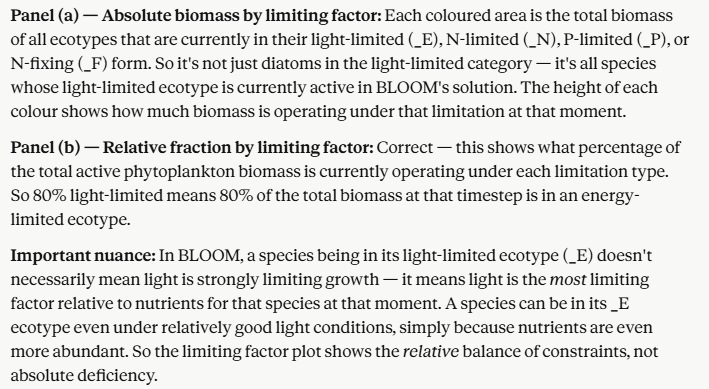

In [28]:
def plot_phyto_summary(R, locs_cab, locs_bis, torch_cab, torch_bis,
                       start='2023-04-01', save_path=None):
    """
    Single figure combining:
    Row 1: Chla time series (layer 8, loc01) + species stacked area (layer 8 loc 01)
    Row 2: Diatom depth-time profile locs 01 + 02
    Row 3: Greens+Flagellates depth-time profile locs 01 + 02
    Row 4: Total phytoplankton depth-time profile locs 01 + 02
    Model output resampled to daily mean for all panels.

    Biomass = sum of ALL BLOOM ecotypes per species. BLOOM _E/_N/_P are
    nutrient-adapted physiological states of one species, each carrying
    carbon biomass (gC/m³) — confirmed by .lst Block 1 (all transported
    constituents) and by the .spe Chlfa reconstruction. They are summed,
    not treated as separate units.
    """
    from matplotlib.patches import Patch

    layer_depths_local = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                          13: 5.0, 14: 6.6, 15: 8.0}
    layer_bounds = {8:(0,0.55), 9:(0.55,1.46), 10:(1.46,2.45),
                    11:(2.45,3.40), 12:(3.40,4.45), 13:(4.45,5.80),
                    14:(5.80,7.30), 15:(7.30,8.30)}

    ts_idx  = R['ts_index']
    mask    = ts_idx >= pd.Timestamp(start)
    ts_plot = ts_idx[mask]

    def daily(arr):
        return pd.Series(arr, index=ts_idx).resample('D').mean()

    def build_profile_matrix(subs, locs, max_depth=8.0):
        layers = [l for l in sorted(locs.keys())
                  if layer_depths_local.get(l, 999) <= max_depth]
        depths = [layer_depths_local[l] for l in layers]
        mat    = np.full((mask.sum(), len(layers)), np.nan)
        for j, l in enumerate(layers):
            total = np.zeros(len(R['timestamps']))
            for s in subs:
                if R['idx'].get(s) is not None:
                    total += get_corrected(R, s, locs[l])
            mat[:, j] = pd.Series(total, index=ts_idx)[mask].values
        mat_d = pd.DataFrame(mat, index=ts_plot).resample('D').mean()
        return mat_d.index, depths, mat_d.values

    def layer8_sum(subs, li):
        total = np.zeros(len(R['timestamps']))
        for s in subs:
            if R['idx'].get(s) is not None:
                total += get_corrected(R, s, li)
        return total

    # ── Species groups — all ecotypes summed per species ──────────────────────
    diat_subs  = ['FDIATOMS_E', 'FDIATOMS_N', 'FDIATOMS_P']
    green_subs = ['GREENS_E', 'GREENS_N', 'GREENS_P', 'FFLAGELA']
    cyan_subs  = ['MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P',
                  'APHANFIX_E', 'APHANFIX_N', 'APHANFIX_P', 'APHANFIX_F',
                  'OSCILAT_E', 'OSCILAT_N', 'OSCILAT_P',
                  'ANABAENA_E', 'ANABAENA_N', 'ANABAENA_P']
    alg_all    = diat_subs + green_subs + cyan_subs   # total phytoplankton

    li_cab8 = locs_cab[8]
    li_bis8 = locs_bis[8]

    # ── Chlfa at layer 8 from model .his ──────────────────────────────────────
    chlfa_source = 'Chlfa (.his)' if R['idx'].get('Chlfa') is not None \
                   else 'fallback (all ecotypes × ChlaCAlg≈0.025)'
    print(f'Chlfa source: {chlfa_source}')

    if R['idx'].get('Chlfa') is not None:
        chlfa_cab = daily(get_corrected(R, 'Chlfa', li_cab8))
    else:
        # Fallback only — sums ALL ecotypes (approximate single 0.025 ratio).
        print('WARNING: Chlfa not in .his — using all-ecotype fallback')
        chlfa_cab = daily(
            sum(get_corrected(R, s, li_cab8) for s in alg_all
                if R['idx'].get(s) is not None) * 0.025 * 1000)

    diat_cab  = daily(layer8_sum(diat_subs,  li_cab8))
    green_cab = daily(layer8_sum(green_subs, li_cab8))
    cyan_cab  = daily(layer8_sum(cyan_subs,  li_cab8))

    ts_daily = pd.date_range(start=start, end=ts_plot[-1], freq='D')

    # ── Profile matrices ───────────────────────────────────────────────────────
    ts_d_cab, dep_cab, mat_diat_cab  = build_profile_matrix(diat_subs,  locs_cab)
    ts_d_bis, dep_bis, mat_diat_bis  = build_profile_matrix(diat_subs,  locs_bis, 7.0)
    _,        _,       mat_green_cab = build_profile_matrix(green_subs, locs_cab)
    _,        _,       mat_green_bis = build_profile_matrix(green_subs, locs_bis, 7.0)
    _,        _,       mat_tot_cab   = build_profile_matrix(alg_all,    locs_cab)
    _,        _,       mat_tot_bis   = build_profile_matrix(alg_all,    locs_bis, 7.0)

    # ── P-limitation periods (share of biomass in P-adapted ecotype) ───────────
    pho_P8   = sum(get_corrected(R, s, li_cab8) for s in
                   ['APHANFIX_P','FDIATOMS_P','GREENS_P','MICROCYS_P',
                    'OSCILAT_P','ANABAENA_P']
                   if R['idx'].get(s) is not None)
    light_E8 = sum(get_corrected(R, s, li_cab8) for s in
                   ['APHANFIX_E','FDIATOMS_E','FFLAGELA','GREENS_E',
                    'MICROCYS_E','OSCILAT_E','ANABAENA_E']
                   if R['idx'].get(s) is not None)
    nit_N8   = sum(get_corrected(R, s, li_cab8) for s in
                   ['APHANFIX_N','GREENS_N','MICROCYS_N','OSCILAT_N','ANABAENA_N']
                   if R['idx'].get(s) is not None)
    tot8     = light_E8 + nit_N8 + pho_P8
    tot8     = np.where(tot8 > 0, tot8, np.nan)
    frac_P8  = pho_P8 / tot8 * 100
    frac_P_s = (pd.Series(np.nan_to_num(frac_P8), index=ts_idx)
                .resample('D').mean()
                .reindex(ts_daily).fillna(0))

    P_THRESHOLD   = 20.0
    p_lim_mask    = frac_P_s > P_THRESHOLD
    p_lim_periods = []
    in_period, start_p = False, None
    for date, is_plim in p_lim_mask.items():
        if is_plim and not in_period:
            start_p = date; in_period = True
        elif not is_plim and in_period:
            p_lim_periods.append((start_p, date)); in_period = False
    if in_period:
        p_lim_periods.append((start_p, p_lim_mask.index[-1]))
    longest = max(p_lim_periods, key=lambda x: x[1] - x[0]) \
              if p_lim_periods else None

    # ── Figure ─────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(11, 11))
    gs  = fig.add_gridspec(4, 2,
                           hspace=0.38, wspace=0.12,
                           left=0.07, right=0.97,
                           top=0.96, bottom=0.05)
    xlim = (pd.Timestamp(start), ts_d_cab[-1])
    xfmt = mdates.DateFormatter('%b\n%Y')
    xloc = mdates.MonthLocator()
    colours_sp = ['#ff7f0e', '#2ca02c', '#9467bd']

    # ── (a) Chlfa — layer 8, Loc 01 ───────────────────────────────────────────
    ax1a = fig.add_subplot(gs[0, 0])
    ax1a.plot(chlfa_cab.index, chlfa_cab.values,
              color='darkgreen', lw=1.2, label='Modelled (0.16 m)')
    ax1a.scatter(torch_cab['Date'], torch_cab['Chloro Tot'],
                 color='red', s=35, zorder=5, label='Observed')
    for i, (s, e) in enumerate(p_lim_periods):
        ax1a.axvspan(s, e, alpha=0.10, color='tomato',
                     label='P-lim period' if i == 0 else None)
    ax1a.set_ylabel('Chl a (µg/L)', fontsize=8)
    ax1a.legend(fontsize=6, loc='upper right')
    ax1a.set_xlim(xlim)
    ax1a.xaxis.set_major_formatter(xfmt)
    ax1a.xaxis.set_major_locator(xloc)
    ax1a.tick_params(labelsize=7)
    ax1a.grid(True, alpha=0.3)
    ax1a.text(0.02, 0.93,
              '(a) Chlorophyll a — Loc 01, layer 8 (0.16 m)\n'
              f'     {chlfa_source}',
              transform=ax1a.transAxes, fontsize=7, va='top')

    # ── (b) Species stacked area — layer 8, Loc 01, all ecotypes ──────────────
    ax1b = fig.add_subplot(gs[0, 1])
    vals = np.array([
        diat_cab.reindex(ts_daily).fillna(0).values,
        green_cab.reindex(ts_daily).fillna(0).values,
        cyan_cab.reindex(ts_daily).fillna(0).values,
    ])
    sp_max = float(np.nanmax(np.sum(vals, axis=0)))

    ax1b.stackplot(ts_daily, vals,
                   labels=['Diatoms', 'Greens+Flagellates', 'Cyanobacteria'],
                   colors=colours_sp, alpha=0.85)

    for s, e in p_lim_periods:
        ax1b.axvspan(s, e, alpha=0.10, color='tomato')

    handles, labels_leg = ax1b.get_legend_handles_labels()
    handles.append(Patch(facecolor='tomato', alpha=0.3))
    labels_leg.append('P-lim period')
    ax1b.legend(handles=handles, labels=labels_leg,
                fontsize=6, loc='upper right', ncol=1)
    ax1b.set_ylabel('Biomass (gC/m³)', fontsize=8)
    ax1b.set_xlim(xlim)
    ax1b.xaxis.set_major_formatter(xfmt)
    ax1b.xaxis.set_major_locator(xloc)
    ax1b.tick_params(labelsize=7)
    ax1b.grid(True, alpha=0.3)
    ax1b.text(0.02, 0.93,
              '(b) Species groups — Loc 01, layer 8 (0.16 m)\n'
              '     total biomass, all ecotypes summed',
              transform=ax1b.transAxes, fontsize=7, va='top')

    # ── Rows 2–4: Depth-time profiles ─────────────────────────────────────────
    # vmax auto-scaled (98th pct): all-ecotype totals are larger than the
    # former _E-only scale, so previous fixed vmax values would saturate.
    profile_data = [
        ('(c) Diatoms — Loc 01',           ts_d_cab, dep_cab,
         mat_diat_cab,  'YlOrBr'),
        ('(d) Diatoms — Loc 02',           ts_d_bis, dep_bis,
         mat_diat_bis,  'YlOrBr'),
        ('(e) Greens+Flag — Loc 01',       ts_d_cab, dep_cab,
         mat_green_cab, 'Greens'),
        ('(f) Greens+Flag — Loc 02',       ts_d_bis, dep_bis,
         mat_green_bis, 'Greens'),
        ('(g) Total phyto — Loc 01',       ts_d_cab, dep_cab,
         mat_tot_cab,   'viridis'),
        ('(h) Total phyto — Loc 02',       ts_d_bis, dep_bis,
         mat_tot_bis,   'viridis'),
    ]

    for idx, (title, ts_d, depths, mat, cmap) in enumerate(profile_data):
        row = 1 + idx // 2
        col = idx % 2
        ax  = fig.add_subplot(gs[row, col])
        vmax = np.nanpercentile(mat, 98) if np.isfinite(mat).any() else 1.0
        pc  = ax.pcolormesh(ts_d, depths, mat.T,
                            cmap=cmap, vmin=0, vmax=vmax,
                            shading='nearest')
        cb  = plt.colorbar(pc, ax=ax, shrink=0.85, pad=0.02)
        cb.ax.tick_params(labelsize=6)
        cb.set_label('gC/m³\n(all ecotypes)', fontsize=7)
        ax.invert_yaxis()
        ax.set_ylabel('Depth (m)', fontsize=8)
        ax.set_xlim(xlim)
        ax.xaxis.set_major_formatter(xfmt)
        ax.xaxis.set_major_locator(xloc)
        ax.tick_params(labelsize=7)

        # P-limitation shading on profiles — top strip
        for s, e in p_lim_periods:
            ax.axvspan(s, e, alpha=0.08, color='tomato')

        ax.text(0.02, 0.96, title,
                transform=ax.transAxes, fontsize=7, va='top',
                color='white',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.4))
        for d in depths:
            ax.axhline(d, color='white', lw=0.3, alpha=0.35)

    fig.text(0.5, 0.002,
             f'Chlfa panel (a): {chlfa_source}.  '
             f'Biomass panels (b–h): total carbon biomass, all ecotypes '
             f'summed (gC/m³).  '
             f'Red shading = P-limitation period (P-type biomass share '
             f'> {P_THRESHOLD}%).',
             ha='center', fontsize=6, color='grey')

    plt.suptitle(
        f'Phytoplankton summary — Loc 01 time series (layer 8) '
        f'and depth profiles (Loc 01 & 02)\n{PRIMARY_RUN}',
        fontsize=10, y=0.998)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()
    plt.close()


# ── Run ────────────────────────────────────────────────────────────────────────
R = load_his(RUNS[PRIMARY_RUN])
plot_phyto_summary(
    R,
    locs_cab  = R['cab_locs'],
    locs_bis  = R['bis_locs'],
    torch_cab = torch_cab,
    torch_bis = torch_bis,
    start     = '2023-04-01',
    save_path = os.path.join(BASE, RUNS[PRIMARY_RUN],
                             'Phyto_ProfileSummary.png'),
)

Loaded: 01scen_baseline
  42 substances, 20 locations, 1253 timesteps
  2023-04-01 -> 2024-02-08
  idx contains 42 substances — Chlfa: 36
Chlfa source: Chlfa (.his)
Saved: <MODEL_DIR>\01scen_baseline\Phyto_ProfileSummary.png


<Figure size 1320x1320 with 14 Axes>

In [29]:
def plot_species_profiles(R, locs, loc_label, max_depth,
                          start='2023-04-01', save_path=None):
    """
    6-panel depth-time profiles for individual species + total.
    One figure per location.
    Panels:
    (a) FDIATOMS — total biomass, all ecotypes summed (gC/m³)
    (b) FFLAGELA — total biomass (gC/m³)
    (c) GREENS   — total biomass, all ecotypes summed (gC/m³)
    (d) MICROCYS — total biomass, all ecotypes summed (gC/m³)
    (e) Total cyanobacteria — all genera, all ecotypes (gC/m³)
    (f) Total phytoplankton — all species, all ecotypes (gC/m³)

    BLOOM _E/_N/_P are nutrient-adapted physiological states of one species,
    each carrying carbon biomass (gC/m³) — confirmed by .lst Block 1 (all
    transported constituents) and by the .spe Chlfa reconstruction. They are
    summed here to give true per-species biomass.
    Red shading = P-limitation period (share of biomass in P-adapted
    ecotype > 20%).
    """
    from matplotlib.patches import Patch

    layer_depths_local = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                          13: 5.0, 14: 6.6, 15: 8.0}
    ts_idx  = R['ts_index']
    mask    = ts_idx >= pd.Timestamp(start)
    ts_plot = ts_idx[mask]

    def build_matrix(subs, max_d=max_depth):
        layers = [l for l in sorted(locs.keys())
                  if layer_depths_local.get(l, 999) <= max_d]
        depths = [layer_depths_local[l] for l in layers]
        mat    = np.full((mask.sum(), len(layers)), np.nan)
        for j, l in enumerate(layers):
            total = np.zeros(len(R['timestamps']))
            for s in subs:
                if R['idx'].get(s) is not None:
                    total += get_corrected(R, s, locs[l])
            mat[:, j] = pd.Series(total, index=ts_idx)[mask].values
        mat_d = pd.DataFrame(mat, index=ts_plot).resample('D').mean()
        return mat_d.index, depths, mat_d.values

    # ── P-limitation periods from layer 8 ─────────────────────────────────────
    li8    = locs[8]
    pho_P8 = sum(get_corrected(R, s, li8) for s in
                 ['APHANFIX_P','FDIATOMS_P','GREENS_P','MICROCYS_P',
                  'OSCILAT_P','ANABAENA_P']
                 if R['idx'].get(s) is not None)
    lig_E8 = sum(get_corrected(R, s, li8) for s in
                 ['FDIATOMS_E','FFLAGELA','GREENS_E','MICROCYS_E']
                 if R['idx'].get(s) is not None)
    nit_N8 = sum(get_corrected(R, s, li8) for s in
                 ['APHANFIX_N','GREENS_N','MICROCYS_N','OSCILAT_N','ANABAENA_N']
                 if R['idx'].get(s) is not None)
    tot8   = lig_E8 + nit_N8 + pho_P8
    tot8   = np.where(tot8 > 0, tot8, np.nan)
    frac_P8 = pho_P8 / tot8 * 100

    ts_d_ref_early, _, _ = build_matrix(['FDIATOMS_E'])
    ts_daily_full = ts_d_ref_early

    frac_P_s = (pd.Series(np.nan_to_num(frac_P8), index=ts_idx)
                .resample('D').mean()
                .reindex(ts_daily_full).fillna(0))

    P_THRESHOLD   = 20.0
    p_lim_mask    = frac_P_s > P_THRESHOLD
    p_lim_periods = []
    in_period, start_p = False, None
    for date, is_plim in p_lim_mask.items():
        if is_plim and not in_period:
            start_p = date; in_period = True
        elif not is_plim and in_period:
            p_lim_periods.append((start_p, date)); in_period = False
    if in_period:
        p_lim_periods.append((start_p, p_lim_mask.index[-1]))

    # ── Panel definitions — all ecotypes summed per species ───────────────────
    cyano_all = ['MICROCYS_E','MICROCYS_N','MICROCYS_P',
                 'APHANFIX_E','APHANFIX_N','APHANFIX_P','APHANFIX_F',
                 'OSCILAT_E','OSCILAT_N','OSCILAT_P',
                 'ANABAENA_E','ANABAENA_N','ANABAENA_P']
    panels = [
        ('(a) Diatoms (all ecotypes)',
         ['FDIATOMS_E','FDIATOMS_N','FDIATOMS_P'],   'YlOrBr'),
        ('(b) Flagellates',
         ['FFLAGELA'],                                'Blues'),
        ('(c) Green algae (all ecotypes)',
         ['GREENS_E','GREENS_N','GREENS_P'],          'Greens'),
        ('(d) Microcystis (all ecotypes)',
         ['MICROCYS_E','MICROCYS_N','MICROCYS_P'],    'Purples'),
        ('(e) Total cyanobacteria (all ecotypes)',
         cyano_all,                                   'RdPu'),
        ('(f) Total phytoplankton (all ecotypes)',
         ['FDIATOMS_E','FDIATOMS_N','FDIATOMS_P','FFLAGELA',
          'GREENS_E','GREENS_N','GREENS_P'] + cyano_all,
         'viridis'),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12.5, 10))
    fig.subplots_adjust(hspace=0.35, wspace=0.22,
                        left=0.07, right=0.97,
                        top=0.93, bottom=0.06)
    xfmt = mdates.DateFormatter('%b\n%Y')
    xloc = mdates.MonthLocator()
    axes_flat = axes.flatten()

    for idx, (title, subs, cmap) in enumerate(panels):
        ax = axes_flat[idx]
        ts_d, dep, mat = build_matrix(subs)

        # vmax auto-scaled per panel (98th pct) — all-ecotype totals exceed
        # the former _E-only scale, so fixed vmax values would saturate.
        vmax = np.nanpercentile(mat, 98) if np.isfinite(mat).any() else 1.0
        pc = ax.pcolormesh(ts_d, dep, mat.T,
                           cmap=cmap, vmin=0, vmax=vmax,
                           shading='nearest')
        cb = plt.colorbar(pc, ax=ax, shrink=0.90, pad=0.02)
        cb.ax.tick_params(labelsize=6)
        cb.set_label('gC/m³\n(all ecotypes)', fontsize=7)
        ax.invert_yaxis()
        ax.set_ylabel('Depth (m)', fontsize=8)
        ax.set_xlim(pd.Timestamp(start), ts_d[-1])
        ax.xaxis.set_major_formatter(xfmt)
        ax.xaxis.set_major_locator(xloc)
        ax.tick_params(labelsize=7)

        # P-limitation shading
        for s, e in p_lim_periods:
            ax.axvspan(s, e, alpha=0.10, color='tomato')

        for d in dep:
            ax.axhline(d, color='white', lw=0.3, alpha=0.35)
        ax.text(0.02, 0.96, title,
                transform=ax.transAxes, fontsize=7, va='top',
                color='white',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.4))

    # Shared legend for P-limitation shading
    fig.legend(
        handles=[Patch(facecolor='tomato', alpha=0.3,
                       label=f'P-limitation period (P-type biomass share '
                             f'> {P_THRESHOLD}%)')],
        loc='lower center', ncol=1, fontsize=7,
        bbox_to_anchor=(0.5, 0.0))

    fig.text(0.5, 0.022,
             'Total carbon biomass per species — all BLOOM ecotypes '
             '(_E/_N/_P) summed (gC/m³).  '
             'Colour scale auto-set per panel (98th pct).  '
             'Model output resampled to daily mean.',
             ha='center', fontsize=6, color='grey')

    plt.suptitle(
        f'Phytoplankton species profiles — {loc_label}\n{PRIMARY_RUN}',
        fontsize=10)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()
    plt.close()


# ── Run ────────────────────────────────────────────────────────────────────────
R = load_his(RUNS[PRIMARY_RUN])
plot_species_profiles(
    R, locs=R['cab_locs'],
    loc_label='Location 01 (CAB)',
    max_depth=8.0, start='2023-04-01',
    save_path=os.path.join(BASE, RUNS[PRIMARY_RUN],
                           'Phyto_SpeciesProfiles_CAB.png'),
)
plot_species_profiles(
    R, locs=R['bis_locs'],
    loc_label='Location 02 (BIS)',
    max_depth=7.0, start='2023-04-01',
    save_path=os.path.join(BASE, RUNS[PRIMARY_RUN],
                           'Phyto_SpeciesProfiles_BIS.png'),
)

Loaded: 01scen_baseline
  42 substances, 20 locations, 1253 timesteps
  2023-04-01 -> 2024-02-08
  idx contains 42 substances — Chlfa: 36
Saved: <MODEL_DIR>\01scen_baseline\Phyto_SpeciesProfiles_CAB.png


<Figure size 1500x1200 with 12 Axes>

Saved: <MODEL_DIR>\01scen_baseline\Phyto_SpeciesProfiles_BIS.png


<Figure size 1500x1200 with 12 Axes>

## 14. Phytoplankton & Chlorophyll (from .his substances)

In [30]:
# ── Section 14: Phytoplankton Summary — Chla, Groups, Limiting Factors ────────
# CORRECTED: BLOOM _E/_N/_P are physiological types of ONE species, each
# carrying CARBON BIOMASS (gC/m3) — confirmed by .lst Block 1 (all listed as
# transported constituents) and by the .spe Chlfa reconstruction matching
# .his Chlfa. They are NOT nutrient content and CAN be summed. Species
# biomass below is therefore the sum of all ecotypes, not _E alone.
from matplotlib.patches import Patch

li     = R['cab_locs'][8]
li_bis = R['bis_locs'][8]
ts_idx = R['ts_index']

def daily(arr):
    return pd.Series(arr, index=ts_idx).resample('D').mean()

ts_daily = pd.date_range(
    start=pd.Timestamp('2023-04-01'),
    end=pd.Timestamp('2023-09-01'),
    freq='D')

# Per-species ecotype groups — sum over ALL ecotypes for total carbon biomass.
SPECIES_ECOTYPES = {
    'Diatoms':       ['FDIATOMS_E', 'FDIATOMS_N', 'FDIATOMS_P'],
    'Greens':        ['GREENS_E', 'GREENS_N', 'GREENS_P'],
    'Flagellates':   ['FFLAGELA'],
    'Cyanobacteria': ['MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P',
                      'APHANFIX_E', 'APHANFIX_N', 'APHANFIX_P', 'APHANFIX_F',
                      'OSCILAT_E', 'OSCILAT_N', 'OSCILAT_P',
                      'ANABAENA_E', 'ANABAENA_N', 'ANABAENA_P'],
}
ALL_ALG = [s for v in SPECIES_ECOTYPES.values() for s in v]

def species_total(R, ecotypes, loc):
    """Sum all available ecotypes of a species => total carbon biomass (gC/m³)."""
    present = [s for s in ecotypes if R['idx'].get(s) is not None]
    if not present:
        return np.zeros(len(R['timestamps']))
    return sum(get_corrected(R, s, loc) for s in present)

# ── Chlfa from .his ───────────────────────────────────────────────────────────
chlfa_source = 'Chlfa (.his)' if R['idx'].get('Chlfa') is not None \
               else 'fallback (all ecotypes × ChlaCAlg≈0.025)'
if R['idx'].get('Chlfa') is not None:
    chlfa_d     = daily(get_corrected(R, 'Chlfa', li)).reindex(ts_daily)
    chlfa_bis_d = daily(get_corrected(R, 'Chlfa', li_bis)).reindex(ts_daily)
else:
    # Fallback only — .his Chlfa is the preferred measure. Sums ALL ecotypes
    # (not _E alone). Approximate: uses a single 0.025 ratio; for a rigorous
    # fallback use the per-type .spe reconstruction in the verification cell.
    print('WARNING: Chlfa not in .his — using all-ecotype fallback (approximate)')
    chlfa_d = daily(
        sum(get_corrected(R, s, li) for s in ALL_ALG
            if R['idx'].get(s) is not None) * 0.025 * 1000
    ).reindex(ts_daily)
    chlfa_bis_d = daily(
        sum(get_corrected(R, s, li_bis) for s in ALL_ALG
            if R['idx'].get(s) is not None) * 0.025 * 1000
    ).reindex(ts_daily)

# ── Species groups — total biomass, all ecotypes summed ───────────────────────
groups = {name: species_total(R, ecos, li)
          for name, ecos in SPECIES_ECOTYPES.items()}
groups_daily = {k: daily(v).reindex(ts_daily).fillna(0)
                for k, v in groups.items()}

# ── Biomass share by adapted ecotype (limitation regime diagnostic) ───────────
# All three sums below are carbon biomass; the ratio is the fraction of total
# phyto biomass that BLOOM has allocated to each nutrient-adapted physiological
# type — a coarse indicator of which resource is limiting growth.
alg_E_all = ['APHANFIX_E','FDIATOMS_E','FFLAGELA','GREENS_E',
             'MICROCYS_E','OSCILAT_E','ANABAENA_E']
light_E = sum(get_corrected(R, s, li) for s in alg_E_all
              if R['idx'].get(s) is not None)
nit_N   = sum(get_corrected(R, s, li) for s in
              ['APHANFIX_N','GREENS_N','MICROCYS_N','OSCILAT_N','ANABAENA_N']
              if R['idx'].get(s) is not None)
pho_P   = sum(get_corrected(R, s, li) for s in
              ['APHANFIX_P','FDIATOMS_P','GREENS_P','MICROCYS_P',
               'OSCILAT_P','ANABAENA_P']
              if R['idx'].get(s) is not None)
nfix_F  = get_corrected(R, 'APHANFIX_F', li) \
          if R['idx'].get('APHANFIX_F') is not None \
          else np.zeros(len(R['timestamps']))

total  = light_E + nit_N + pho_P + nfix_F
total  = np.where(total > 0, total, np.nan)
frac_E = light_E / total * 100
frac_N = nit_N   / total * 100
frac_P = pho_P   / total * 100
frac_F = nfix_F  / total * 100

frac_E_d = daily(np.nan_to_num(frac_E)).reindex(ts_daily)
frac_N_d = daily(np.nan_to_num(frac_N)).reindex(ts_daily)
frac_P_d = daily(np.nan_to_num(frac_P)).reindex(ts_daily)
frac_F_d = daily(np.nan_to_num(frac_F)).reindex(ts_daily)

# ── P-limitation periods (biomass-in-P-type > threshold) ──────────────────────
P_THRESHOLD   = 20.0
p_lim_mask    = frac_P_d > P_THRESHOLD
p_lim_periods = []
in_period, start_p = False, None
for date, is_plim in p_lim_mask.items():
    if is_plim and not in_period:
        start_p = date; in_period = True
    elif not is_plim and in_period:
        p_lim_periods.append((start_p, date)); in_period = False
if in_period:
    p_lim_periods.append((start_p, p_lim_mask.index[-1]))
longest = max(p_lim_periods, key=lambda x: x[1] - x[0]) \
          if p_lim_periods else None

print(f'P-limitation periods (P-type biomass share > {P_THRESHOLD}%):')
for s, e in p_lim_periods:
    print(f'  {s.date()} → {e.date()}')

# ── Plot ───────────────────────────────────────────────────────────────────────
colours_sp  = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
lim_colours = ['gold', 'steelblue', 'tomato', 'mediumpurple']
lim_labels  = ['Energy/light-adapted (_E)', 'N-adapted (_N)',
                'P-adapted (_P)', 'N-fixing type (_F)']

fig, axes = plt.subplots(3, 1, figsize=(6, 5.5), sharex=True)

# (a) Chlorophyll a
axes[0].plot(ts_daily, chlfa_d, color='darkgreen', lw=1.0,
             label='Modelled Loc 01 (0.16 m)')
axes[0].plot(ts_daily, chlfa_bis_d, color='darkgreen', lw=1.0, ls='--',
             label='Modelled Loc 02 (0.16 m)')
axes[0].scatter(torch_cab['Date'], torch_cab['Chloro Tot'],
                color='red', s=40, zorder=5, label='Observed Loc 01')
axes[0].scatter(torch_bis['Date'], torch_bis['Chloro Tot'],
                color='darkorange', marker='^', s=40, zorder=5,
                label='Observed Loc 02')
for i, (s, e) in enumerate(p_lim_periods):
    axes[0].axvspan(s, e, alpha=0.10, color='tomato',
                    label='P-lim period' if i == 0 else None)
axes[0].set_ylabel('Chl a [µg/L]', fontsize=8)
axes[0].legend(fontsize=6, loc='upper left', ncol=2)
axes[0].tick_params(axis='both', labelsize=7)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(
    f'(a) Chlorophyll a — layer 8 (0.16 m) | {chlfa_source}',
    fontsize=7, loc='left')

# (b) Species groups — total biomass, all ecotypes summed
vals   = np.array([np.nan_to_num(v.values) for v in groups_daily.values()])
sp_max = float(np.nanmax(np.sum(vals, axis=0)))

axes[1].stackplot(ts_daily, vals, labels=list(groups_daily.keys()),
                  colors=colours_sp, alpha=0.85)
for s, e in p_lim_periods:
    axes[1].axvspan(s, e, alpha=0.10, color='tomato')
handles, labels_leg = axes[1].get_legend_handles_labels()
handles.append(Patch(facecolor='tomato', alpha=0.3))
labels_leg.append('P-lim period')
axes[1].legend(handles=handles, labels=labels_leg,
               fontsize=6, loc='upper right', ncol=2)
axes[1].set_ylabel('Biomass [gC/m³]', fontsize=8)
axes[1].tick_params(axis='both', labelsize=7)
axes[1].grid(True, alpha=0.3)
axes[1].set_title(
    '(b) Species groups — total biomass (all ecotypes summed), layer 8 (0.16 m)',
    fontsize=7, loc='left')

# (c) Biomass share by adapted ecotype
axes[2].stackplot(ts_daily,
                  [frac_E_d.values, frac_N_d.values,
                   frac_P_d.values, frac_F_d.values],
                  labels=lim_labels, colors=lim_colours, alpha=0.85)
axes[2].set_ylabel('Share of biomass [%]', fontsize=8)
axes[2].set_ylim(0, 100)
axes[2].yaxis.set_major_locator(plt.MultipleLocator(25))
axes[2].legend(fontsize=6, loc='lower left', ncol=2)
axes[2].tick_params(axis='both', labelsize=7)
axes[2].grid(True, alpha=0.3)
axes[2].set_title(
    '(c) Limitation regime — share of total biomass by adapted ecotype\n'
    '     _E/_N/_P = energy/N/P-limited physiological state (all carbon biomass)',
    fontsize=7, loc='left')

for ax in axes:
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())

fig.text(0.5, -0.025,
         f'Panel (a): {chlfa_source}.  '
         f'Red shading = P-limitation period (P-type biomass share > {P_THRESHOLD}%).\n'
         'Panel (b): total biomass per species, all ecotypes summed (gC/m³).  '
         'Panel (c): same biomass, split by which nutrient-adapted ecotype it sits in.',
         ha='center', fontsize=6, color='grey', linespacing=1.6)

plt.tight_layout()
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'Phyto_Summary_CAB.png'),
            dpi=150, bbox_inches='tight')
plt.show()

P-limitation periods (P-type biomass share > 20.0%):
  2023-04-01 → 2023-04-02
  2023-06-12 → 2023-07-18
  2023-07-19 → 2023-07-20


<Figure size 720x660 with 3 Axes>

In [31]:
li     = R['cab_locs'][8]
li_layer9     = R['cab_locs'][9]
li_bis = R['bis_locs'][8]
li_bis_layer9 = R['bis_locs'][9]
ts_idx = R['ts_index']

def daily(arr):
    return pd.Series(arr, index=ts_idx).resample('D').mean()

ts_daily = pd.date_range(
    start=pd.Timestamp('2023-04-01'),
    end=pd.Timestamp('2023-09-01'),
    freq='D')

# ── Chlfa from .his ───────────────────────────────────────────────────────────
chlfa_d     = daily(get_corrected(R, 'Chlfa', li)).reindex(ts_daily)
chlfa_d_layer9     = daily(get_corrected(R, 'Chlfa', li_layer9)).reindex(ts_daily)

chlfa_bis_d = daily(get_corrected(R, 'Chlfa', li_bis)).reindex(ts_daily)
chlfa_bis_d_layer9 = daily(get_corrected(R, 'Chlfa', li_bis_layer9)).reindex(ts_daily)

# ── Plot ───────────────────────────────────────────────────────────────────────
colours_sp  = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
lim_colours = ['gold', 'steelblue', 'tomato', 'mediumpurple']
lim_labels  = ['Energy/light-adapted (_E)', 'N-adapted (_N)',
                'P-adapted (_P)', 'N-fixing type (_F)']

fig, axes = plt.subplots(2, 1, figsize=(5, 3.8), sharex = True)

# Chlorophyll a - Location 01
axes[0].plot(ts_daily, chlfa_d, color='darkgreen', lw=1.0, linestyle = '-',
             label='Modelled (max 0.16 m)')
axes[0].plot(ts_daily, chlfa_d_layer9, color='darkgreen', lw=1.0, linestyle = '--',
             label='Modelled (max 0.93 m)')
axes[0].scatter(torch_cab['Date'], torch_cab['Chloro Tot'],
                color='red', s=40, zorder=5, label='Observed Loc 01')

axes[0].set_ylabel('Chlorophyll a [µg/L]', fontsize=9)
axes[0].legend(fontsize=7, loc='upper left', ncol=1)
axes[0].tick_params(axis='both', labelsize=9)
axes[0].grid(True, alpha=0.3)

axes[0].set_title('(a) Location 01',fontsize=8, loc='left')

# Chlorophyll a - Location 02
axes[1].plot(ts_daily, chlfa_bis_d, color='mediumpurple', lw=1.0, ls='-',
             label='Modelled (max 0.16 m)')
axes[1].plot(ts_daily, chlfa_bis_d_layer9, color='mediumpurple', lw=1.0, ls='--',
             label='Modelled (max 0.93 m)')
axes[1].scatter(torch_bis['Date'], torch_bis['Chloro Tot'],
                color='darkorange', marker='^', s=40, zorder=5,
                label='Observed Loc 02')
axes[1].set_ylabel('Chlorophyll a [µg/L]', fontsize=9)
axes[1].legend(fontsize=7, loc='upper left', ncol=1)
axes[1].tick_params(axis='both', labelsize=9)
axes[1].grid(True, alpha=0.3)

axes[1].set_title('(b) Location 02',fontsize=8, loc='left')

axes[-1].set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'Chla_calibration.png'),
            dpi=150, bbox_inches='tight')
plt.show()

<Figure size 600x456 with 2 Axes>

In [40]:
# ── Verification: reconstruct Chlfa from .spe stoichiometry ─────────────────────
# .lst Block 1 confirms the algae types are transported substances => carbon
# biomass (gC/m3). .his Chlfa = sum_type[ biomass * Chla:C ]; it is not
# contaminated by "non-biomass". This cell verifies that and quantifies the
# error of an _E-only sum.

SPE_PATH = os.path.join(BASE, RUNS[PRIMARY_RUN], 'bloom.spe')   # <-- set filename

# ── Load .his (add if R not already in namespace) ───────────────────────────────
R = load_his(RUNS[PRIMARY_RUN])

# Algae substances in this run (from .lst Block 1, constituents 12-20)
ALGAE_TYPES = ['FDIATOMS_E', 'FDIATOMS_P', 'FFLAGELA',
               'GREENS_E', 'GREENS_N', 'GREENS_P',
               'MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P']

def parse_spe_chlac(spe_path):
    """Return {type_name: Chla:C (gChla/gC)} from the .spe algae database.
    CHLACALG is the 9th of the 28 coefficient columns; on each data row the
    28 coefficients are the last 28 whitespace-separated tokens."""
    ratios = {}
    with open(spe_path) as f:
        for line in f:
            tok = line.split()
            if len(tok) < 33:                  # 5+ label fields + 28 coefficients
                continue
            try:
                coeffs = [float(t.replace('D', 'E').replace('d', 'E'))
                          for t in tok[-28:]]
            except ValueError:
                continue                       # header or non-data row
            ratios[tok[2]] = coeffs[8]         # TYPE column ; CHLACALG = coeff #9
    return ratios

chlac = parse_spe_chlac(SPE_PATH)
print('Per-type Chla:C from .spe (gChla/gC):')
for t in ALGAE_TYPES:
    print(f'  {t:<14s} {chlac.get(t, float("nan")):.4f}'
          + ('' if t in chlac else '   <-- NOT FOUND in .spe'))

def chlfa_from_spe(R, locs, layer, types, ratios, e_only=False):
    """Chlfa (ug/L) = sum_type[ biomass_gC/m3 * Chla:C ] * 1000.
    biomass from .his algae substances ; Chla:C from .spe.
    e_only=True sums only energy types (the underestimate to quantify)."""
    loc, total = locs[layer], None
    for t in types:
        if e_only and not t.endswith('_E') and t != 'FFLAGELA':
            continue
        if R['idx'].get(t) is None or t not in ratios:
            print(f'  skipped {t}: missing in .his or .spe')
            continue
        bio = pd.Series(get_corrected(R, t, loc), index=R['ts_index'])
        contrib = bio * ratios[t] * 1000.0
        total = contrib if total is None else total + contrib
    return total.resample('D').mean()

# ── Compute for CAB, surface layer 8 ────────────────────────────────────────────
LAYER = 8
chlfa_recon = chlfa_from_spe(R, R['cab_locs'], LAYER, ALGAE_TYPES, chlac)
chlfa_eonly = chlfa_from_spe(R, R['cab_locs'], LAYER, ALGAE_TYPES, chlac, e_only=True)
chlfa_his = (pd.Series(get_corrected(R, 'Chlfa', R['cab_locs'][LAYER]),
                       index=R['ts_index']).resample('D').mean()
             if R['idx'].get('Chlfa') is not None else None)

# ── Compare ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(chlfa_recon.index, chlfa_recon, lw=1.6, color='#1f77b4',
         label='Reconstructed from .spe (all types)')
if chlfa_his is not None:
    ax1.plot(chlfa_his.index, chlfa_his, lw=1.0, color='k', ls='--',
             label='.his Chlfa (BLOOM internal)')
ax1.plot(chlfa_eonly.index, chlfa_eonly, lw=1.2, color='#d62728', alpha=0.8,
         label='_E types only (underestimate)')
ax1.set_ylabel('Chlfa (µg/L)')
ax1.legend(fontsize=8, frameon=False)
ax1.set_title(f'Chlfa reconstruction check — CAB, layer {LAYER}  ({PRIMARY_RUN})',
              fontsize=10)

if chlfa_his is not None:
    resid = (chlfa_recon - chlfa_his).reindex(chlfa_his.index)
    ax2.axhline(0, color='grey', lw=0.6)
    ax2.plot(resid.index, resid, lw=1.0, color='#555555')
    ax2.set_ylabel('recon − .his\n(µg/L)', fontsize=8)
    rmse = float(np.sqrt(np.nanmean(resid.values ** 2)))
    maxd = float(np.nanmax(np.abs(resid.values)))
    print(f'\nReconstructed vs .his Chlfa:  RMSE = {rmse:.3f} µg/L, '
          f'max |diff| = {maxd:.3f} µg/L')

frac = (chlfa_eonly / chlfa_recon * 100).replace([np.inf, -np.inf], np.nan)
summer = (frac.index.month >= 6) & (frac.index.month <= 8)
print('\n_E-only sum vs all-ecotype reconstruction (Chla equivalent):')
print(f'  annual mean  : {frac.mean():.1f}%  '
      f'(diluted by spring, when _E dominates)')
print(f'  Jun-Aug mean : {frac[summer].mean():.1f}%   '
      f'min: {frac[summer].min():.1f}%')
print('  => in the bloom window most biomass sits in the _N/_P ecotypes, so an')
print('     _E-only plot understates summer biomass severely. Use .his Chlfa or')
print('     this all-ecotype reconstruction for total biomass.')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.show()
plt.close()

Loaded: 01scen_baseline
  42 substances, 20 locations, 1253 timesteps
  2023-04-01 -> 2024-02-08
  idx contains 42 substances — Chlfa: 36
Per-type Chla:C from .spe (gChla/gC):
  FDIATOMS_E     0.0250
  FDIATOMS_P     0.0250
  FFLAGELA       0.0290
  GREENS_E       0.0250
  GREENS_N       0.0250
  GREENS_P       0.0250
  MICROCYS_E     0.0250
  MICROCYS_N     0.0170
  MICROCYS_P     0.0170

Reconstructed vs .his Chlfa:  RMSE = 1.427 µg/L, max |diff| = 4.350 µg/L

_E-only sum vs all-ecotype reconstruction (Chla equivalent):
  annual mean  : 80.7%  (diluted by spring, when _E dominates)
  Jun-Aug mean : 68.8%   min: 0.0%
  => in the bloom window most biomass sits in the _N/_P ecotypes, so an
     _E-only plot understates summer biomass severely. Use .his Chlfa or
     this all-ecotype reconstruction for total biomass.


<Figure size 1080x720 with 2 Axes>

## Summary stats

In [33]:
from scipy import stats

# ── Section X: Summary statistics — modelled vs observed ──────────────────────
# All variables with measured data at CAB location.
# Metrics: n, Mean_obs, Mean_mod, Bias, RMSE, r

# ── Secchi helper — define here in case Section 11 not in scope ───────────────
def secchi_from_his(R, cab, max_depth=4.45):
    """Read SecchiDept from .his — falls back to 1.7/Kd if not present."""
    layer_depths_kd = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9}
    layer_bounds_kd = {8:(0,0.55), 9:(0.55,1.46), 10:(1.46,2.45),
                       11:(2.45,3.40), 12:(3.40,4.45)}
    if R['idx'].get('SecchiDept') is not None:
        s = pd.Series(get_corrected(R, 'SecchiDept', cab[8]),
                      index=R['ts_index']).resample('D').mean()
        return s, 'SecchiDept (.his)'
    else:
        layers = [l for l in sorted(cab.keys())
                  if layer_depths_kd.get(l, 999) <= max_depth
                  and l in layer_bounds_kd]
        total_thick = sum(layer_bounds_kd[l][1] - layer_bounds_kd[l][0]
                          for l in layers)
        result = np.zeros(len(R['timestamps']))
        for l in layers:
            thick = layer_bounds_kd[l][1] - layer_bounds_kd[l][0]
            ev = get_corrected(R, 'ExtVl', cab[l])
            if ev is not None:
                result += ev * (thick / total_thick)
        kd = pd.Series(result, index=R['ts_index']).resample('D').mean()
        s = kd.apply(lambda k: 1.7/k if k > 0 else np.nan)
        return s, '1.7/Kd (fallback)'

ts_idx = R['ts_index']

# ====================== ALIGNMENT FUNCTIONS ======================
def align_mod_obs(mod_series, obs_series):
    """
    Align modelled (daily) and observed (point) series.
    Handles observations with time component by grouping to daily.
    """
    obs_clean = obs_series.dropna()
    if len(obs_clean) == 0:
        return None, None, 0

    mod_daily = mod_series.resample('D').mean()

    if isinstance(obs_clean.index, pd.DatetimeIndex):
        obs_daily = obs_clean.groupby(obs_clean.index.normalize()).mean()
    else:
        obs_daily = obs_clean.groupby(pd.to_datetime(obs_clean.index).normalize()).mean()

    common = mod_daily.index.intersection(obs_daily.index)
    if len(common) == 0:
        return None, None, 0

    mod_v = mod_daily.loc[common].values
    obs_v = obs_daily.loc[common].values
    mask = ~np.isnan(mod_v) & ~np.isnan(obs_v)
   
    return mod_v[mask], obs_v[mask], mask.sum()


def align_mod_obs_hourly(mod_series, obs_series):
    """Resample both to daily mean."""
    obs_daily = obs_series.resample('D').mean().dropna()
    mod_daily = mod_series.resample('D').mean()
   
    common = mod_daily.index.intersection(obs_daily.index)
    if len(common) == 0:
        return None, None, 0
       
    mod_v = mod_daily.loc[common].values
    obs_v = obs_daily.loc[common].values
    mask = ~np.isnan(mod_v) & ~np.isnan(obs_v)
    return mod_v[mask], obs_v[mask], mask.sum()


def compute_metrics(mod_v, obs_v):
    """Compute Bias, RMSE, r, MAE."""
    if mod_v is None or len(mod_v) < 2:
        return dict(n=0, mean_obs=np.nan, mean_mod=np.nan,
                    bias=np.nan, rmse=np.nan, r=np.nan, mae=np.nan)
    bias = float(np.mean(mod_v - obs_v))
    rmse = float(np.sqrt(np.mean((mod_v - obs_v)**2)))
    mae = float(np.mean(np.abs(mod_v - obs_v)))
    r, _ = stats.pearsonr(mod_v, obs_v) if len(mod_v) > 2 else (np.nan, np.nan)
    return dict(
        n = len(mod_v),
        mean_obs = float(np.mean(obs_v)),
        mean_mod = float(np.mean(mod_v)),
        bias = bias,
        rmse = rmse,
        r = r,
        mae = mae,
    )


# ====================== DATA PROCESSING ======================
rows = []

# ── 1. DO at 0.7m ───────────────────────────────────────
w1, w2 = 0.30, 0.70
do_mod = pd.Series(
    w1 * get_corrected(R, 'OXY', R['cab_locs'][8]) +
    w2 * get_corrected(R, 'OXY', R['cab_locs'][9]),
    index=ts_idx)

mod_v, obs_v, n = align_mod_obs_hourly(do_mod, obs_hourly['DO_obs'])
m = compute_metrics(mod_v, obs_v)
rows.append({'Variable': 'DO (g/m³)', 'Location': 'CAB 0.7m',
             'Source': 'Sensor (hourly→daily)', **m})

# ── 2. Chlfa — algae torch ───────────────────────────────────────
if R['idx'].get('Chlfa') is not None:
    chlfa_mod = pd.Series(get_corrected(R, 'Chlfa', R['cab_locs'][8]), index=ts_idx)
else:
    # Fallback only — .his Chlfa is preferred. Sum ALL ecotypes (BLOOM
    # _E/_N/_P each carry carbon biomass); single 0.025 ratio is approximate.
    alg_all = ['FDIATOMS_E','FDIATOMS_N','FDIATOMS_P','FFLAGELA',
               'GREENS_E','GREENS_N','GREENS_P',
               'MICROCYS_E','MICROCYS_N','MICROCYS_P']
    chlfa_mod = pd.Series(
        sum(get_corrected(R, s, R['cab_locs'][8]) for s in alg_all
            if R['idx'].get(s) is not None) * 0.025 * 1000,
        index=ts_idx)

torch_cab_s = torch_cab.set_index('Date')['Chloro Tot']
mod_v, obs_v, n = align_mod_obs(chlfa_mod, torch_cab_s)
m = compute_metrics(mod_v, obs_v)
rows.append({'Variable': 'Chlfa (ug/L)', 'Location': 'CAB layer 8',
             'Source': 'Algae Torch', **m})

# BIS torch
if R['idx'].get('Chlfa') is not None:
    chlfa_bis = pd.Series(get_corrected(R, 'Chlfa', R['bis_locs'][8]), index=ts_idx)
else:
    chlfa_bis = pd.Series(
        sum(get_corrected(R, s, R['bis_locs'][8]) for s in alg_all
            if R['idx'].get(s) is not None) * 0.025 * 1000,
        index=ts_idx)

torch_bis_s = torch_bis.set_index('Date')['Chloro Tot']
mod_v, obs_v, n = align_mod_obs(chlfa_bis, torch_bis_s)
m = compute_metrics(mod_v, obs_v)
rows.append({'Variable': 'Chlfa (ug/L)', 'Location': 'BIS layer 8',
             'Source': 'Algae Torch', **m})

# ── 3. Secchi depth ────────────────────────────────────────────────────────────
sb, _ = secchi_from_his(R, R['cab_locs'])
secchi_obs_s = secchi_obs.set_index('time')['Secchi_m']
mod_v, obs_v, n = align_mod_obs(sb, secchi_obs_s)
m = compute_metrics(mod_v, obs_v)
rows.append({'Variable': 'Secchi depth (m)', 'Location': 'CAB',
             'Source': 'Direct observation', **m})

# ── 4. Nutrients ───────────────────────────────────────────────────────────────
layer_depths_s = {8: 0.16, 9: 0.93, 10: 2.0, 11: 2.9, 12: 3.9,
                  13: 5.0, 14: 6.6, 15: 8.0}
layer_bounds_s = {8:(0,0.55), 9:(0.55,1.46), 10:(1.46,2.45),
                  11:(2.45,3.40), 12:(3.40,4.45), 13:(4.45,5.80),
                  14:(5.80,7.30), 15:(7.30,8.30)}

def davg(sub, factor=1.0):
    """Thickness-weighted depth average (0-8 m) of one .his substance."""
    layers = [l for l in sorted(R['cab_locs'].keys())
              if layer_depths_s.get(l, 999) <= 8.0 and l in layer_bounds_s]
    total_thick = sum(layer_bounds_s[l][1] - layer_bounds_s[l][0] for l in layers)
    result = np.zeros(len(R['timestamps']))
    if R['idx'].get(sub) is not None:
        for l in layers:
            thick = layer_bounds_s[l][1] - layer_bounds_s[l][0]
            val = get_corrected(R, sub, R['cab_locs'][l])
            if val is not None:
                result += val * (thick / total_thick)
    return pd.Series(result * factor, index=ts_idx)

def davg_sum(subs, factor=1.0):
    """Depth-averaged sum of several substances (e.g. all N pools)."""
    out = pd.Series(np.zeros(len(R['timestamps'])), index=ts_idx)
    for s in subs:
        if R['idx'].get(s) is not None:
            out = out + davg(s, 1.0)
    return out * factor

def davg_id(series, factor=1.0):
    """Apply a unit factor to an already-computed depth-averaged Series."""
    return series * factor

# ── Total N / Total P — composed: TotN and TotP are NOT in this .his ──────────
# DELWAQ tracks N and P across dissolved, detrital, adsorbed and algal pools.
# Total N = DIN (NH4+NO3) + organic/particulate N (PON1) + algal-bound N.
# Total P = PO4 + adsorbed P (AAP) + particulate organic P (POP1) + algal-bound P.
# Algal N/P live in the BLOOM substances; BLOOM N:C and P:C ratios are NOT
# constant, so algal N/P cannot be recovered exactly from carbon biomass alone.

# (1) Does the observed N_Total include nitrate? TKN excludes it; TN includes it.
TN_INCLUDES_NITRATE = True   # <-- SET THIS for your lab dataset

# (2) Include algal-bound N/P in the modelled total?
#     This .his has no AlgN/AlgP output, so an exact algal term is unavailable.
#     INCLUDE_ALG=False compares the observed total against the model's
#     NON-algal N/P pools only — a defined, reproducible quantity, but it will
#     under-read the true total when biomass is high. Correct only if the
#     observations are filtered (dissolved+detrital, no plankton).
#     To include algae exactly: add AlgN/AlgP to the .his history block, rerun.
INCLUDE_ALG = False

n_pools = ['NH4', 'PON1'] + (['NO3'] if TN_INCLUDES_NITRATE else [])
p_pools = ['PO4', 'POP1']

totn_mod = davg_sum(n_pools)          # gN/m3
totp_mod = davg_sum(p_pools)          # gP/m3

totn_note = ('DIN+PON1' if TN_INCLUDES_NITRATE else 'NH4+PON1 (TKN-like)')
totp_note = 'PO4+AAP+POP1'
if INCLUDE_ALG:
    if R['idx'].get('AlgN') is not None:
        totn_mod = totn_mod + davg('AlgN'); totn_note += '+AlgN'
    if R['idx'].get('AlgP') is not None:
        totp_mod = totp_mod + davg('AlgP'); totp_note += '+AlgP'
    if R['idx'].get('AlgN') is None and R['idx'].get('AlgP') is None:
        print('NOTE: INCLUDE_ALG=True but no AlgN/AlgP in .his — '
              'algal N/P NOT included; totals are non-algal pools only.')

print(f'Modelled TotN = depth-avg({totn_note});  '
      f'TotP = depth-avg({totp_note}).  '
      f'Algal-bound N/P {"included" if "Alg" in totn_note else "EXCLUDED"}.')

# Modelled nutrients are in g/m3, and 1 g/m3 == 1 mg/L exactly.
# Convert ONLY where the observed column is in different units.
#   - mg/L observed  -> model factor 1     (g/m3 == mg/L)
#   - ug/L observed  -> model factor 1000  (mg/L -> ug/L)
nutrient_pairs = [
    # name (units = OBSERVED column units)     model factor   obs column
    (f'TotN (mgN/L) [{totn_note}]', davg_id(totn_mod, 1),    obs_chem['N_Total'],     'Chemistry'),
    (f'TotP (ugP/L) [{totp_note}]', davg_id(totp_mod, 1000), obs_chem['P_Total_ugL'], 'Chemistry'),
    ('PO4 (mgP/L)',   davg('PO4', 1),  obs_chem['P_PO4'], 'Chemistry'),
    ('NH4 (mgN/L)',   davg('NH4', 1),  obs_chem['N_NH4'], 'Chemistry'),
    ('NO3 (mgN/L)',   davg('NO3', 1),  obs_chem['N_NO3'], 'Chemistry'),
    ('SiO2 (mgSi/L)', davg('Si',  1),  obs_chem['SiO2'],  'Chemistry'),
]

for var_name, mod_s, obs_s, source in nutrient_pairs:
    obs_clean = obs_s.dropna() if hasattr(obs_s, 'dropna') else pd.Series(obs_s).dropna()
    if len(obs_clean) == 0:
        continue
    mod_v, obs_v, n = align_mod_obs(mod_s, obs_clean)
    m = compute_metrics(mod_v, obs_v)
    rows.append({'Variable': var_name, 'Location': 'CAB depth-avg 0-8m',
                 'Source': source, **m})

# ====================== BUILD TABLE ======================
df_stats = pd.DataFrame(rows)
df_stats = df_stats[['Variable','Location','Source','n',
                      'mean_obs','mean_mod','bias','rmse','r','mae']]
df_stats.columns = ['Variable','Location','Source','n',
                    'Mean obs','Mean mod','Bias','RMSE','r','MAE']

for col in ['Mean obs','Mean mod','Bias','RMSE','r','MAE']:
    df_stats[col] = df_stats[col].round(3)

# ====================== PRINT & SAVE ======================
print('MODEL PERFORMANCE SUMMARY — CAB Location')
print('='*90)
print(df_stats.to_string(index=False))

csv_path = os.path.join(BASE, RUNS[PRIMARY_RUN], 'Model_Performance_Summary.csv')
df_stats.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')

# ====================== PLOTS ======================
df_plot = df_stats[df_stats['n'] > 0].copy()

# Shortened labels for better display
var_labels = [f"{r['Variable'].split('(')[0].strip()}\n({r['Location'].split()[0]})"
              for _, r in df_plot.iterrows()]

# ── Heatmap ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['Bias', 'RMSE', 'r']
cmaps = ['RdBu_r', 'Reds', 'RdYlGn']
labels = ['Bias (mod-obs)', 'RMSE', 'Pearson r']

for ax, metric, cmap, label in zip(axes, metrics, cmaps, labels):
    vals = df_plot[metric].values.reshape(-1, 1)
    if metric == 'Bias':
        lim = max(abs(np.nanmin(vals)), abs(np.nanmax(vals)))
        vmin, vmax = -lim, lim
    elif metric == 'r':
        vmin, vmax = -1, 1
    else:
        vmin, vmax = 0, np.nanmax(vals) or 1

    im = ax.imshow(vals, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_yticks(range(len(var_labels)))
    ax.set_yticklabels(var_labels, fontsize=8)
    ax.set_xticks([])
    ax.set_title(label, fontsize=10)
    
    for i, v in enumerate(vals.flatten()):
        if not np.isnan(v):
            ax.text(0, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
                    fontweight='bold',
                    color='white' if abs(v) > 0.6*max(abs(vmin),abs(vmax)) else 'black')

plt.suptitle('Model performance summary — CAB\nAll variables with observations', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'Model_Performance_Heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ── Bar chart with improved x-axis labels ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))   # Wider figure

x = np.arange(len(df_plot))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_plot)))

# RMSE Bar
ax = axes[0]
bars = ax.bar(x, df_plot['RMSE'].values, color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(var_labels, fontsize=8, rotation=45, ha='right')
ax.set_ylabel('RMSE', fontsize=9)
ax.set_title('(a) RMSE by variable', fontsize=10, loc='left')
ax.grid(True, alpha=0.3, axis='y')

# r Bar
ax = axes[1]
r_vals = df_plot['r'].values
colors_r = ['#2ca02c' if v > 0.5 else '#ff7f0e' if v > 0.3 else '#d62728' for v in r_vals]
bars = ax.bar(x, r_vals, color=colors_r, alpha=0.85, edgecolor='white')

ax.axhline(0.5, color='grey', lw=0.8, ls='--', label='r=0.5')
ax.axhline(0.3, color='lightgrey', lw=0.8, ls='--', label='r=0.3')
ax.set_xticks(x)
ax.set_xticklabels(var_labels, fontsize=8, rotation=45, ha='right')
ax.set_ylabel('Pearson r', fontsize=9)
ax.set_ylim(-1, 1.1)
ax.set_title('(b) Pearson r by variable', fontsize=10, loc='left')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=8)

plt.suptitle('Model performance — RMSE and correlation by variable', fontsize=11)
plt.subplots_adjust(bottom=0.28)      # Extra space for rotated labels
plt.tight_layout()
plt.savefig(os.path.join(BASE, RUNS[PRIMARY_RUN], 'Model_Performance_Bars.png'),
            dpi=150, bbox_inches='tight')
plt.show()

Modelled TotN = depth-avg(DIN+PON1);  TotP = depth-avg(PO4+AAP+POP1).  Algal-bound N/P EXCLUDED.
MODEL PERFORMANCE SUMMARY — CAB Location
                   Variable           Location                Source   n  Mean obs  Mean mod   Bias   RMSE      r    MAE
                  DO (g/m³)           CAB 0.7m Sensor (hourly→daily) 154    10.149     8.613 -1.536  1.934  0.362  1.629
               Chlfa (ug/L)        CAB layer 8           Algae Torch   5     1.533     9.424  7.891 11.340 -0.658  7.891
               Chlfa (ug/L)        BIS layer 8           Algae Torch   4     1.392    10.789  9.398 12.649 -0.578  9.398
           Secchi depth (m)                CAB    Direct observation   5     4.152     4.517  0.365  1.398 -0.715  1.200
    TotN (mgN/L) [DIN+PON1] CAB depth-avg 0-8m             Chemistry   5     1.253     1.197 -0.056  0.276  0.894  0.267
TotP (ugP/L) [PO4+AAP+POP1] CAB depth-avg 0-8m             Chemistry   5    11.951    26.928 14.978 15.926  0.318 14.978
               

<Figure size 1680x600 with 6 Axes>

<Figure size 1680x600 with 2 Axes>

In [34]:
# ── Compact summary table: RMSE + Bias only ───────────────────────────────────
# Filter to variables with observations, keep only RMSE and Bias plus
# identifying columns. Same metric definitions and units as the parent table.

df_short = df_stats[df_stats['n'] > 0][
    ['Variable', 'Location', 'Source', 'n', 'Bias', 'RMSE']
].copy().reset_index(drop=True)

print('RMSE and Bias summary — modelled vs observed at CAB')
print('=' * 90)
print(df_short.to_string(index=False))

csv_short = os.path.join(BASE, RUNS[PRIMARY_RUN], 'Model_RMSE_Bias_Summary.csv')
df_short.to_csv(csv_short, index=False)
print(f'\nSaved: {csv_short}')

RMSE and Bias summary — modelled vs observed at CAB
                   Variable           Location                Source   n   Bias   RMSE
                  DO (g/m³)           CAB 0.7m Sensor (hourly→daily) 154 -1.536  1.934
               Chlfa (ug/L)        CAB layer 8           Algae Torch   5  7.891 11.340
               Chlfa (ug/L)        BIS layer 8           Algae Torch   4  9.398 12.649
           Secchi depth (m)                CAB    Direct observation   5  0.365  1.398
    TotN (mgN/L) [DIN+PON1] CAB depth-avg 0-8m             Chemistry   5 -0.056  0.276
TotP (ugP/L) [PO4+AAP+POP1] CAB depth-avg 0-8m             Chemistry   5 14.978 15.926
                PO4 (mgP/L) CAB depth-avg 0-8m             Chemistry   5  0.018  0.018
                NH4 (mgN/L) CAB depth-avg 0-8m             Chemistry   5  0.042  0.055
                NO3 (mgN/L) CAB depth-avg 0-8m             Chemistry   5  0.021  0.244
              SiO2 (mgSi/L) CAB depth-avg 0-8m             Chemistry   5 -0.35

In [35]:
# ── Compact summary table: RMSE + Bias only — Excel-friendly export ──────────
# Filter to variables with observations, keep only RMSE and Bias plus
# identifying columns. Saved as CSV with UTF-8 BOM so Excel renders µ, ³
# correctly on double-click.

df_short = df_stats[df_stats['n'] > 0][
    ['Variable', 'Location', 'Source', 'n', 'Bias', 'RMSE']
].copy().reset_index(drop=True)

# Strip newlines and excess whitespace from text columns — keeps each row on
# one Excel line. (Some variable names in df_stats contain embedded notes
# like '[DIN+PON1]' that are fine but we collapse any stray whitespace.)
for col in ['Variable', 'Location', 'Source']:
    df_short[col] = (df_short[col].astype(str)
                                  .str.replace(r'\s+', ' ', regex=True)
                                  .str.strip())

print('RMSE and Bias summary — modelled vs observed at CAB')
print('=' * 90)
print(df_short.to_string(index=False))
print('\nBias convention: modelled - observed  (positive = model overpredicts)')

# UTF-8 BOM lets Excel auto-detect encoding and render µ, ³, ° correctly.
csv_short = os.path.join(BASE, RUNS[PRIMARY_RUN], 'Model_RMSE_Bias_Summary.csv')
df_short.to_csv(csv_short, index=False, encoding='utf-8-sig')
print(f'\nSaved (UTF-8 with BOM, Excel-ready): {csv_short}')

RMSE and Bias summary — modelled vs observed at CAB
                   Variable           Location                Source   n   Bias   RMSE
                  DO (g/m³)           CAB 0.7m Sensor (hourly→daily) 154 -1.536  1.934
               Chlfa (ug/L)        CAB layer 8           Algae Torch   5  7.891 11.340
               Chlfa (ug/L)        BIS layer 8           Algae Torch   4  9.398 12.649
           Secchi depth (m)                CAB    Direct observation   5  0.365  1.398
    TotN (mgN/L) [DIN+PON1] CAB depth-avg 0-8m             Chemistry   5 -0.056  0.276
TotP (ugP/L) [PO4+AAP+POP1] CAB depth-avg 0-8m             Chemistry   5 14.978 15.926
                PO4 (mgP/L) CAB depth-avg 0-8m             Chemistry   5  0.018  0.018
                NH4 (mgN/L) CAB depth-avg 0-8m             Chemistry   5  0.042  0.055
                NO3 (mgN/L) CAB depth-avg 0-8m             Chemistry   5  0.021  0.244
              SiO2 (mgSi/L) CAB depth-avg 0-8m             Chemistry   5 -0.35

In [51]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL TO ADD AT THE END OF THE ANALYSIS NOTEBOOK
# ══════════════════════════════════════════════════════════════════════════════
 
# ── Generate PowerPoint — Analysis notebook ───────────────────────────────────
# Assembles all plots from the analysis run into a structured presentation.
# Save generate_pptx.py in the same folder as this notebook before running.
 
import subprocess
import os
 
# Path to the generator script — place it alongside this notebook
SCRIPT   = r'<MODEL_DIR>\generate_pptx.py'
 
# Run directory — folder where all analysis PNGs were saved
RUN_DIR  = os.path.join(BASE, RUNS[PRIMARY_RUN])
 
# Output PowerPoint path
OUT_PPTX = os.path.join(BASE, RUNS[PRIMARY_RUN],
                         f'Torun_WAQ_Analysis_{PRIMARY_RUN}.pptx')
 
import subprocess
import os
import sys

SCRIPT   = r'<MODEL_DIR>\generate_pptx.py'
RUN_DIR  = os.path.join(BASE, RUNS[PRIMARY_RUN])
OUT_PPTX = os.path.join(BASE, RUNS[PRIMARY_RUN],
                         f'Torun_WAQ_Analysis_{PRIMARY_RUN}.pptx')

print(f'Script:  {SCRIPT}  exists={os.path.exists(SCRIPT)}')
print(f'Run dir: {RUN_DIR}  exists={os.path.exists(RUN_DIR)}')
print(f'Output:  {OUT_PPTX}')

result = subprocess.run(
    [sys.executable, SCRIPT,
     '--mode',    'analysis',
     '--run_dir', RUN_DIR,
     '--out',     OUT_PPTX],
    capture_output=True, text=True, encoding='utf-8'
)

print(f'Return code: {result.returncode}')
print(f'STDOUT:\n{result.stdout}')
print(f'STDERR:\n{result.stderr}')

Script:  <MODEL_DIR>\generate_pptx.py  exists=True
Run dir: <MODEL_DIR>\output_data_run42  exists=True
Output:  <MODEL_DIR>\output_data_run42\Torun_WAQ_Analysis_Run42 (FasterSinking+spefile).pptx
Return code: 0
STDOUT:
Written: <MODEL_DIR>\output_data_run42\Torun_WAQ_Analysis_Run42 (FasterSinking+spefile).pptx

STDERR:

